# Thesis — AIMS Rwanda
## Computer Vision for Multi-Category African Plum (*Safou*) Defect Detection

- **Author:** Darix Samani Siewe
- **Institution:** African Institute for Mathematical Sciences (AIMS), Rwanda
- **Program:** Master of Science in Mathematical Sciences

---

## Overview

This notebook contains the complete implementation of my master's thesis conducted at **AIMS Rwanda**, focused on the automatic detection and classification of defects in the **African Plum**, commonly known as **Safou** (*Dacryodes edulis*). This work sits at the intersection of **deep learning**, **computer vision**, and **agricultural technology**, with a direct application to food quality control in Central and West African markets.

---

## Motivation & Background

The African Plum (Safou) is a highly nutritious fruit widely cultivated and consumed across Central and West Africa. Despite its economic and nutritional importance, post-harvest quality assessment remains a largely **manual and inconsistent process**, leading to significant food waste and financial losses for farmers and distributors.

Traditional visual inspection by human experts is:
- **Time-consuming** and prone to fatigue
- **Inconsistent** across different inspectors
- **Unscalable** for industrial-level sorting

This thesis proposes an automated, deep learning-based solution capable of identifying and categorizing multiple types of defects on Safou fruits with high accuracy and efficiency.

---

## Objectives

The main objectives of this research are:

1. **Build** a multi-category defect detection model tailored to Safou fruits using state-of-the-art computer vision techniques.
2. **Train** the model on a curated dataset of annotated Safou images representing various defect categories (e.g., bruised, cracked, rotten, spotted, unaffected, unripe).
3. **Validate** the model's performance using standard evaluation metrics such as accuracy, precision, recall, F1-score, and confusion matrices.
4. **Contribute** a reproducible and open pipeline that can serve as a foundation for agricultural AI solutions in African contexts.

---

## Technical Stack

This notebook is built entirely using **Python** and the following core libraries:

| Library | Role |
|---|---|
| `PyTorch` | Model architecture, training loop, and inference |
| `torchvision` | Pre-trained backbone models and image transforms |
| `NumPy` / `Pandas` | Data manipulation and analysis |
| `Matplotlib` / `Seaborn` | Visualization of results and metrics |
| `scikit-learn` | Evaluation metrics and data splitting utilities |
| `Pillow (PIL)` | Image loading and preprocessing |

The deep learning framework of choice is **PyTorch**, selected for its flexibility, dynamic computation graph, and strong community support in research settings.

---

## Notebook Structure

The notebook is organized into the following sections:

1. **Environment Setup** — Installing dependencies and configuring the runtime
2. **Dataset Loading & Exploration** — Understanding the data distribution and visualizing samples
3. **Data Preprocessing & Augmentation** — Applying transforms to improve model generalization
4. **Model Architecture** — Defining and customizing the neural network
5. **Training Pipeline** — Implementing the training and validation loop
6. **Results & Evaluation** — Analyzing model performance with metrics and plots
7. **Conclusion & Future Work** — Summarizing findings and proposing next steps

---

> *This work is submitted in partial fulfillment of the requirements for the Master of Science degree at the African Institute for Mathematical Sciences (AIMS), Rwanda.*

## 1. Environment Setup — Installing Dependencies & Configuring the Runtime

This section walks through every step required to build a clean, reproducible Python environment for running the Safou defect detection notebook. By the end of this section you will have **JupyterLab** running with all the necessary scientific and deep-learning packages installed and ready to use.

---

### 1.1 Why UV?

To simplify and accelerate the environment setup, we use **[UV](https://github.com/astral-sh/uv)** — an extremely fast Python package and project manager written in Rust. UV is a modern drop-in replacement for `pip` and `venv` that offers:

- ⚡ **10–100× faster** installs compared to standard `pip`
- 🔒 **Deterministic dependency resolution** to avoid version conflicts
- 🧹 **Isolated tool environments** that keep global Python clean
- 🖥️ **Cross-platform support** (Windows, macOS, Linux)

> **Note:** Make sure you have **Python 3.9+** installed before proceeding. You can verify your Python version with:
> ```bash
> python3 --version
> ```

---

### 1.2 Installing UV

Install UV using `pip` with the following command:

```bash
pip install uv
```

Once installed, verify the installation was successful:

```bash
uv --version
```

You should see an output similar to `uv 0.x.x`. UV is now ready to manage your tools and packages.

---

### 1.3 Installing JupyterLab

We use **JupyterLab** as our interactive development environment. It provides a browser-based interface for writing and executing code, visualizing results, and documenting the entire workflow inline.

Install JupyterLab as a UV-managed tool:

```bash
uv tool install jupyterlab
```

> **Already have JupyterLab installed?** Run the following command to upgrade it to the latest version instead:
> ```bash
> uv tool upgrade jupyterlab
> ```

After installation, you can launch JupyterLab at any time with:

```bash
jupyter-lab
```

This will open JupyterLab in your default browser at `http://localhost:8888`.

---

### 1.4 Installing Required Packages

Our notebook relies on several Python packages for data manipulation, visualization, and deep learning. We install all of them in a single command using UV's `--with` flag, which bundles all dependencies into the JupyterLab tool environment:

```bash
uv tool install jupyterlab \
  --with torch \
  --with torchvision \
  --with tensorflow \
  --with numpy \
  --with pandas \
  --with matplotlib \
  --with scipy \
  --with pillow
```

> **On Windows**, replace the backslashes `\` with backticks `` ` `` if using PowerShell, or write the full command on a single line.

---

### 1.5 Package Reference

Here is a summary of every package installed and its role in this project:

| Package | Version (Recommended) | Purpose |
|---|---|---|
| `torch` | ≥ 2.0 | Core deep learning framework (PyTorch) — model building, training, and inference |
| `torchvision` | ≥ 0.15 | Pre-trained models, image transforms, and computer vision datasets |
| `tensorflow` | ≥ 2.12 | Secondary framework used for benchmarking and comparison |
| `numpy` | ≥ 1.24 | Numerical computing and array operations |
| `pandas` | ≥ 2.0 | Data loading, manipulation, and tabular analysis |
| `matplotlib` | ≥ 3.7 | Plotting training curves, confusion matrices, and sample images |
| `scipy` | ≥ 1.10 | Scientific computing utilities (statistics, signal processing) |
| `pillow` | ≥ 10.0 | Image loading, saving, and preprocessing (reading PNG/JPEG Safou images) |

---

### 1.6 Verifying the Installation

Once everything is installed, open a new notebook cell and run the following code to confirm all packages are correctly loaded and their versions are displayed:

```python
import torch
import torchvision
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib
import scipy
import PIL

print(f"PyTorch       : {torch.__version__}")
print(f"Torchvision   : {torchvision.__version__}")
print(f"TensorFlow    : {tf.__version__}")
print(f"NumPy         : {np.__version__}")
print(f"Pandas        : {pd.__version__}")
print(f"Matplotlib    : {matplotlib.__version__}")
print(f"SciPy         : {scipy.__version__}")
print(f"Pillow         : {PIL.__version__}")

# Check GPU availability
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"\nUsing device  : {device.upper()}")
```

If everything is set up correctly, you will see the version numbers printed for each library, along with a message indicating whether a **GPU (CUDA)** or **CPU** will be used for training.

> **GPU Recommendation:** Training deep learning models is significantly faster on a GPU. If you have access to a CUDA-compatible NVIDIA GPU, make sure the appropriate CUDA toolkit is installed alongside PyTorch. Visit the [PyTorch installation page](https://pytorch.org/get-started/locally/) for GPU-specific installation commands.

---

> ✅ **Environment setup is complete.** Proceed to **Section 2 — Dataset Loading & Exploration** to begin working with the Safou image dataset.

In [1]:
# Verifying the Installation¶

import torch
import torchvision
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib
import scipy
import PIL
import sklearn

print(f"PyTorch       : {torch.__version__}")
print(f"Torchvision   : {torchvision.__version__}")
print(f"TensorFlow    : {tf.__version__}")
print(f"NumPy         : {np.__version__}")
print(f"Pandas        : {pd.__version__}")
print(f"Matplotlib    : {matplotlib.__version__}")
print(f"SciPy         : {scipy.__version__}")
print(f"Pillow         : {PIL.__version__}")
print(f"Scikit-learn         : {sklearn.__version__}")

I0000 00:00:1780039061.028581    6030 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780039062.430612    6030 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


PyTorch       : 2.11.0+cu130
Torchvision   : 0.26.0+cu130
TensorFlow    : 2.21.0
NumPy         : 2.4.4
Pandas        : 3.0.2
Matplotlib    : 3.10.9
SciPy         : 1.17.1
Pillow         : 12.2.0
Scikit-learn         : 1.8.0


## 2. Dataset Loading & Exploration

### 2.1 Dataset

We use the publicly available **[African Plum (Safou) Defect Detection Dataset](https://dx.doi.org/10.1016/j.dib.2025.111351)**, published in *Data in Brief* (2025). The dataset contains labeled images of Safou fruits across multiple defect categories, designed specifically for computer vision classification tasks.

---

### 2.2 Configuration

All dataset paths are centralized in a single configuration block. **Update only this block** if your folder structure changes — the rest of the code adapts automatically.

```python

In [2]:
"""
African Plums Dataset — PyTorch Loader & Category Visualization
================================================================
Requirements:
    pip install torch torchvision pandas matplotlib Pillow
 
Dataset layout expected:
    african_plums/
    ├── bruised/      (319 images)
    ├── cracked/      (162 images)
    ├── rotten/       (720 images)
    ├── spotted/      (759 images)
    ├── unaffected/   (1721 images)
    ├── unripe/       (826 images)
    └── plums_data.csv
"""
 
import os
import random
from pathlib import Path
 
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from PIL import Image
 
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
 
 
# ──────────────────────────────────────────────────────────────
# 1.  DATASET CLASS
# ──────────────────────────────────────────────────────────────
 
class AfricanPlumsDataset(Dataset):
    """
    Custom PyTorch Dataset for the African Plums dataset.
 
    Args:
        root_dir  (str | Path): Path to the `african_plums/` base directory.
        csv_file  (str | Path): Path to `plums_data.csv` (defaults to
                                <root_dir>/plums_data.csv).
        transform (callable):  Optional torchvision transform pipeline.
        split     (str):       'train', 'val', or None (use all data).
        val_frac  (float):     Fraction held out for validation (default 0.15).
        seed      (int):       Random seed for reproducible splits.
    """
 
    CATEGORIES = ["bruised", "cracked", "rotten", "spotted", "unaffected", "unripe"]
 
    # Palette matched to each category
    PALETTE = {
        "bruised":    "#8B4513",   # saddle-brown
        "cracked":    "#A0522D",   # sienna
        "rotten":     "#556B2F",   # dark-olive
        "spotted":    "#CD853F",   # peru
        "unaffected": "#228B22",   # forest-green
        "unripe":     "#6B8E23",   # olive-drab
    }
 
    def __init__(
        self,
        root_dir: str | Path,
        csv_file: str | Path | None = None,
        transform=None,
        split: str | None = None,
        val_frac: float = 0.15,
        seed: int = 42,
    ):
        self.root_dir = Path(root_dir)
        csv_path = Path(csv_file) if csv_file else self.root_dir / "plums_data.csv"
 
        self.df = pd.read_csv(csv_path)
        # Normalize column names to lowercase + underscore
        self.df.columns = [c.strip().lower().replace(" ", "_") for c in self.df.columns]
        # Expected columns after normalization: image_id, label, defect_type
 
        # Encode category → integer
        self.class_to_idx = {cat: i for i, cat in enumerate(self.CATEGORIES)}
        self.idx_to_class = {i: cat for cat, i in self.class_to_idx.items()}
 
        # Optional train / val split
        if split is not None:
            rng = random.Random(seed)
            indices = list(range(len(self.df)))
            rng.shuffle(indices)
            val_n = int(len(indices) * val_frac)
            val_idx = set(indices[:val_n])
            train_idx = set(indices[val_n:])
            keep = val_idx if split == "val" else train_idx
            self.df = self.df.iloc[sorted(keep)].reset_index(drop=True)
 
        self.transform = transform
 
    # ── helpers ───────────────────────────────────────────────
 
    def _image_path(self, row) -> Path:
        defect = row["defect_type"].strip().lower()
        image_id = str(row["image_id"]).strip()
        return self.root_dir / defect / f"{image_id}.png"
 
    # ── standard Dataset API ──────────────────────────────────
 
    def __len__(self) -> int:
        return len(self.df)
 
    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        img_path = self._image_path(row)
        image = Image.open(img_path).convert("RGB")
 
        if self.transform:
            image = self.transform(image)
 
        label = self.class_to_idx[row["defect_type"].strip().lower()]
        return image, label
 
    # ── convenience ───────────────────────────────────────────
 
    def samples_for_category(self, category: str, n: int = 5, seed: int = 0):
        """Return n random (PIL.Image, label) pairs for a given category."""
        subset = self.df[self.df["defect_type"].str.lower() == category.lower()]
        rows = subset.sample(min(n, len(subset)), random_state=seed)
        images = []
        for _, row in rows.iterrows():
            path = self._image_path(row)
            images.append(Image.open(path).convert("RGB"))
        return images

## 3. Data Preprocessing & Augmentation

### 3.1 Why Transforms Matter

Before feeding images into the model, each image must go through a **transformation pipeline** that standardizes its format and prepares it for training. We define two separate pipelines:

- **Training pipeline** — includes data augmentation techniques to artificially increase dataset diversity and improve model generalization.
- **Validation pipeline** — applies only the essential transforms (resize + normalize), ensuring evaluation is done on clean, unaltered images.

> ⚠️ **Never apply augmentation to the validation set.** Augmentation is exclusively a training technique — adding it to validation would corrupt the evaluation metrics.

---

### 3.2 Normalization Values

Both pipelines normalize pixel values using the **ImageNet mean and standard deviation**. This is standard practice when using pre-trained backbones (e.g., ResNet, EfficientNet), as these models were originally trained on ImageNet-normalized data.

| Channel | Mean | Std |
|---|---|---|
| Red   | 0.485 | 0.229 |
| Green | 0.456 | 0.224 |
| Blue  | 0.406 | 0.225 |

---

### 3.3 Augmentation Strategy (Training Only)

| Transform | Parameters | Purpose |
|---|---|---|
| `RandomHorizontalFlip` | — | Simulates fruits seen from different orientations |
| `RandomVerticalFlip` | — | Adds additional rotational variability |
| `ColorJitter` | brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05 | Mimics varying lighting and camera conditions |

---

> ✅ **Transforms are ready.** Proceed to **Section 4 — Model Architecture**.

In [3]:
# ──────────────────────────────────────────────────────────────
# 2.  TRANSFORMS
# ──────────────────────────────────────────────────────────────
 
def get_transforms(image_size: int = 224):
    """Return train and val transform pipelines."""
    train_tf = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])
    val_tf = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])
    return train_tf, val_tf

In [4]:
ROOT = Path("data/african_plums")          # ← change this if needed
CSV_FILE = Path("data/organized_plums_data_new.csv")
IMAGE_SIZE = 224
BATCH_SIZE = 32
N_WORKERS = 4

print("🔍  Loading dataset …")

train_tf, val_tf = get_transforms(IMAGE_SIZE)

# Full dataset (no transform) for visualisation
full_dataset = AfricanPlumsDataset(root_dir=ROOT, csv_file=CSV_FILE,)

# Split datasets with transforms
train_dataset = AfricanPlumsDataset(root_dir=ROOT,csv_file=CSV_FILE, transform=train_tf,
                                    split="train", val_frac=0.15)
val_dataset   = AfricanPlumsDataset(root_dir=ROOT, csv_file=CSV_FILE, transform=val_tf,
                                    split="val",   val_frac=0.15)

print(f"   Total  : {len(full_dataset):,} images")
print(f"   Train  : {len(train_dataset):,} images")
print(f"   Val    : {len(val_dataset):,}  images")
print(f"   Classes: {full_dataset.CATEGORIES}")

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=N_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=N_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print(f"\n   Train batches: {len(train_loader)}")
print(f"   Val   batches: {len(val_loader)}")

🔍  Loading dataset …
   Total  : 4,507 images
   Train  : 3,831 images
   Val    : 676  images
   Classes: ['bruised', 'cracked', 'rotten', 'spotted', 'unaffected', 'unripe']

   Train batches: 120
   Val   batches: 22


## 2.5 Visualization — Sample Images per Category

To better understand the dataset, we display a **structured grid of sample images** where each row corresponds to a defect category and each column is a randomly selected image from that category. This makes it easy to visually assess class diversity, image quality, and potential labeling issues at a glance.

Key design choices in this visualization:

- **Color-coded borders** — each category has a unique color applied to the image border and row label, making categories instantly distinguishable.
- **Configurable sampling** — `n_per_category` and `seed` control how many images are shown and ensure reproducibility.
- **Auto-save** — the figure is saved to disk by default (`african_plums_preview.png`) for use in reports or presentations.

> 💡 **Tip:** Increase `n_per_category` to `10` for a broader inspection, or set `save_path=None` to skip saving and display only in the notebook.

In [5]:
# ──────────────────────────────────────────────────────────────
# 3.  VISUALIZATION — one subplot per category
# ──────────────────────────────────────────────────────────────
 
def plot_category_samples(
    dataset: AfricanPlumsDataset,
    n_per_category: int = 5,
    image_size: int = 128,
    seed: int = 0,
    save_path: str | None = "african_plums_preview.png",
):
    """
    Create a grid of sample images: rows = categories, cols = samples.
 
    Args:
        dataset        : An AfricanPlumsDataset instance (no transform needed).
        n_per_category : Number of sample images to show per category.
        image_size     : Resize images to this square size for display.
        seed           : Random seed for sampling.
        save_path      : If set, save the figure to this path.
    """
    categories = AfricanPlumsDataset.CATEGORIES
    n_rows = len(categories)
    n_cols = n_per_category
 
    fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(n_cols * 2.4, n_rows * 2.6),
    constrained_layout=True)
 
    resize = transforms.Resize((image_size, image_size))
 
    for row_idx, category in enumerate(categories):
        color = AfricanPlumsDataset.PALETTE[category]
        images = dataset.samples_for_category(category, n=n_per_category, seed=seed)
 
        for col_idx in range(n_cols):
            ax = axes[row_idx][col_idx]
            ax.set_xticks([])
            ax.set_yticks([])
 
            if col_idx < len(images):
                img = resize(images[col_idx])
                ax.imshow(img)
                # Coloured border per category
                for spine in ax.spines.values():
                    spine.set_edgecolor(color)
                    spine.set_linewidth(3)
            else:
                ax.set_visible(False)
 
        # Category label on the left of each row
        axes[row_idx][0].set_ylabel(
            category.upper(),
            fontsize=11,
            fontweight="bold",
            color=color,
            rotation=90,
            labelpad=8,
        )
 
    # Column headers (sample index)
    for col_idx in range(n_cols):
        axes[0][col_idx].set_title(f"#{col_idx + 1}", fontsize=9, color="#555555", pad=4)
 
    fig.suptitle(
        "African Plums Dataset — Sample Images per Category",
        fontsize=15,
        fontweight="bold",
        y=1.01,
        color="#2c2c2c",
    )
 
    # Legend
    patches = [
        mpatches.Patch(color=AfricanPlumsDataset.PALETTE[c], label=c.capitalize())
        for c in categories
    ]
    fig.legend(
        handles=patches,
        loc="lower center",
        ncol=len(categories),
        fontsize=9,
        frameon=False,
        bbox_to_anchor=(0.5, -0.02),
    )
 
    #plt.tight_layout()
 
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"✅  Figure saved → {save_path}")
 
    plt.show()
    return fig


📊  Plotting category samples …
✅  Figure saved → african_plums_preview.png


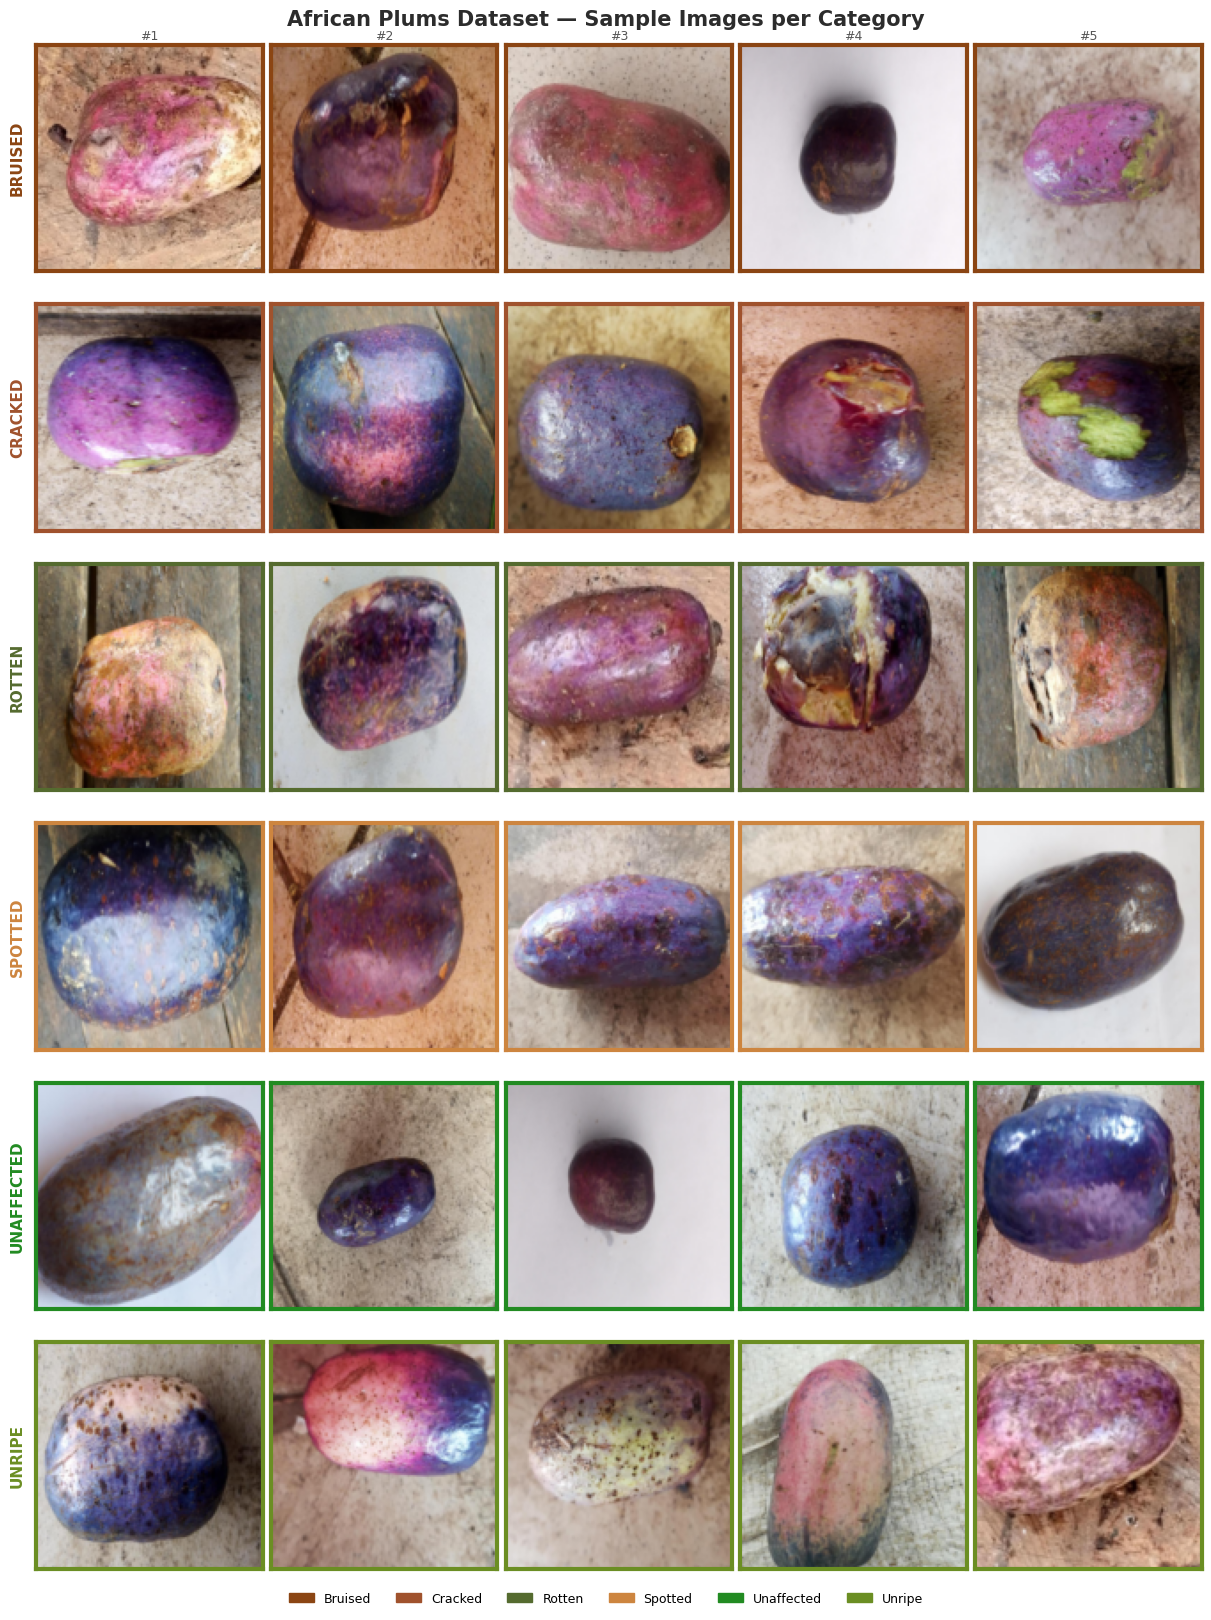


✔  Batch shape : torch.Size([32, 3, 224, 224])
✔  Labels shape: torch.Size([32])
✔  Device      : cpu


In [6]:
# ── Visualise one sample batch ──────────────────────────
print("\n📊  Plotting category samples …")
plot_category_samples(
    dataset=full_dataset,
    n_per_category=5,
    image_size=128,
    seed=42,
    save_path="african_plums_preview.png",
)

# ── Quick sanity-check on one batch ────────────────────
images, labels = next(iter(train_loader))
print(f"\n✔  Batch shape : {images.shape}")   # e.g. [32, 3, 224, 224]
print(f"✔  Labels shape: {labels.shape}")    # e.g. [32]
print(f"✔  Device      : {images.device}")

### Display the Distribution of the Full Dataset

The purpose of this function is to compute, visualize, and export the distribution of the entire dataset. It generates graphical representations that provide insights into data patterns, variability, and potential imbalances. The resulting plots are saved in PNG format for easy sharing, reporting, and further analysis.

In [7]:
# ──────────────────────────────────────────────────────────────
# 4.  VISUALIZATION — full dataset distribution dashboard
# ──────────────────────────────────────────────────────────────
import numpy as np

def plot_dataset_distribution(
    dataset: AfricanPlumsDataset,
    save_path: str | None = "african_plums_distribution.png",
    dpi: int = 160,
    dark: bool = True,
):
    """
    Render a four-panel distribution dashboard for the full dataset:
 
        ┌────────────────────────────┬──────────────┐
        │  Horizontal bar chart      │  Donut chart │
        │  (count + % per category)  │  (proportion)│
        ├────────────────────────────┼──────────────┤
        │  Stacked bar               │  Stats card  │
        │  (label breakdown)         │  (key facts) │
        └────────────────────────────┴──────────────┘
 
    Args:
        dataset   : An AfricanPlumsDataset instance.
        save_path : File path for the saved figure (PNG/PDF/SVG).
                    Pass None to skip saving.
        dpi       : Resolution of the saved figure.
        dark      : Use dark theme (True) or light theme (False).
    """
    import matplotlib.patheffects as pe
 
    # ── theme ─────────────────────────────────────────────────
    if dark:
        BG       = "#0F1117"
        PANEL    = "#161B22"
        BORDER   = "#30363D"
        TEXT_PRI = "#E6EDF3"
        TEXT_SEC = "#8B949E"
        TEXT_MID = "#C9D1D9"
    else:
        BG       = "#F6F8FA"
        PANEL    = "#FFFFFF"
        BORDER   = "#D0D7DE"
        TEXT_PRI = "#1F2328"
        TEXT_SEC = "#656D76"
        TEXT_MID = "#424A53"
 
    PALETTE = AfricanPlumsDataset.PALETTE
    LABEL_GROUP = {
        "bruised":    "defective",
        "cracked":    "defective",
        "rotten":     "defective",
        "spotted":    "defective",
        "unaffected": "unaffected",
        "unripe":     "unripe",
    }
    GROUP_COLOR = {
        "defective":  "#C0622A",
        "unaffected": "#2E8B57",
        "unripe":     "#7BA05B",
    }
 
    # ── counts ────────────────────────────────────────────────
    cats   = AfricanPlumsDataset.CATEGORIES
    counts = np.array([
        len(dataset.df[dataset.df["defect_type"].str.lower() == c])
        for c in cats
    ])
    total  = counts.sum()
    pcts   = counts / total * 100
    colors = [PALETTE[c] for c in cats]
 
    # ── layout ────────────────────────────────────────────────
    fig = plt.figure(figsize=(16, 9), facecolor=BG)
    fig.patch.set_facecolor(BG)
 
    gs = fig.add_gridspec(
        2, 3,
        left=0.06, right=0.97,
        top=0.88,  bottom=0.10,
        hspace=0.52, wspace=0.35,
    )
    ax_bar  = fig.add_subplot(gs[0, :2])
    ax_pie  = fig.add_subplot(gs[0,  2])
    ax_lbl  = fig.add_subplot(gs[1, :2])
    ax_stat = fig.add_subplot(gs[1,  2])
 
    for ax in [ax_bar, ax_pie, ax_lbl, ax_stat]:
        ax.set_facecolor(PANEL)
        for spine in ax.spines.values():
            spine.set_edgecolor(BORDER)
            spine.set_linewidth(0.6)
 
    # ── panel 1 · horizontal bar chart ───────────────────────
    order  = np.argsort(counts)          # ascending (smallest at top)
    cats_s = [cats[i]   for i in order]
    cnts_s = [counts[i] for i in order]
    cols_s = [colors[i] for i in order]
    pcts_s = [pcts[i]   for i in order]
 
    y    = np.arange(len(cats))
    bars = ax_bar.barh(y, cnts_s, color=cols_s, height=0.62, zorder=3)
 
    ax_bar.xaxis.grid(True, color=BORDER, linewidth=0.5, zorder=0)
    ax_bar.set_axisbelow(True)
    ax_bar.set_yticks(y)
    ax_bar.set_yticklabels(
        [c.upper() for c in cats_s],
        fontsize=9, color=TEXT_MID, fontfamily="monospace",
    )
    ax_bar.set_xlabel("Image count", fontsize=8, color=TEXT_SEC, labelpad=6)
    ax_bar.tick_params(axis="x", colors=TEXT_SEC, labelsize=8)
    ax_bar.tick_params(axis="y", length=0)
 
    for bar, cnt, pct in zip(bars, cnts_s, pcts_s):
        ax_bar.text(
            bar.get_width() + max(cnts_s) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{cnt:,}  ({pct:.1f}%)",
            va="center", ha="left",
            fontsize=8.5, color=TEXT_MID, fontfamily="monospace",
        )
 
    ax_bar.set_xlim(0, max(cnts_s) * 1.32)
    ax_bar.set_title(
        "Images per category", fontsize=10, color=TEXT_PRI,
        pad=8, loc="left", fontweight="bold",
    )
 
    # ── panel 2 · donut chart ─────────────────────────────────
    wedges, _ = ax_pie.pie(
        counts,
        colors=colors,
        startangle=90,
        counterclock=False,
        wedgeprops=dict(width=0.42, edgecolor=PANEL, linewidth=2),
    )
    ax_pie.text(0,  0.08, f"{total:,}", ha="center", va="center",
                fontsize=15, fontweight="bold", color=TEXT_PRI,
                fontfamily="monospace")
    ax_pie.text(0, -0.18, "total", ha="center", va="center",
                fontsize=8, color=TEXT_SEC, fontfamily="monospace")
    ax_pie.set_title(
        "Distribution", fontsize=10, color=TEXT_PRI,
        pad=10, loc="left", fontweight="bold",
    )
 
    # ── panel 3 · stacked label breakdown bar ─────────────────
    group_counts: dict[str, int] = {}
    for cat, cnt in zip(cats, counts):
        g = LABEL_GROUP[cat]
        group_counts[g] = group_counts.get(g, 0) + int(cnt)
 
    left_cursor = 0
    for g, gcnt in group_counts.items():
        ax_lbl.barh([0], [gcnt], left=left_cursor,
                    color=GROUP_COLOR[g], height=0.55, zorder=3)
        cx = left_cursor + gcnt / 2
        ax_lbl.text(
            cx, 0,
            f"{g}\n{gcnt:,}  ({gcnt / total * 100:.1f}%)",
            ha="center", va="center",
            fontsize=8.5, color="white",
            fontfamily="monospace", fontweight="bold",
            path_effects=[pe.withStroke(linewidth=2, foreground=PANEL)],
        )
        left_cursor += gcnt
 
    ax_lbl.set_xlim(0, total)
    ax_lbl.set_ylim(-0.5, 0.5)
    ax_lbl.axis("off")
    ax_lbl.set_title(
        "Label breakdown  (defective / unaffected / unripe)",
        fontsize=10, color=TEXT_PRI, pad=8, loc="left", fontweight="bold",
    )
 
    # ── panel 4 · stats card ──────────────────────────────────
    ax_stat.axis("off")
    ax_stat.set_title(
        "Dataset stats", fontsize=10, color=TEXT_PRI,
        pad=8, loc="left", fontweight="bold",
    )
 
    max_cat = cats[int(np.argmax(counts))]
    min_cat = cats[int(np.argmin(counts))]
    defective_n = sum(
        int(cnt) for cat, cnt in zip(cats, counts)
        if LABEL_GROUP[cat] == "defective"
    )
    stats = [
        ("Total images",    f"{total:,}"),
        ("Categories",      "6"),
        ("Max class",       f"{max_cat}  ({counts.max():,})"),
        ("Min class",       f"{min_cat}  ({counts.min():,})"),
        ("Imbalance ratio", f"{counts.max() / counts.min():.1f}×"),
        ("Defective share", f"{defective_n / total * 100:.1f} %"),
    ]
    for i, (lbl, val) in enumerate(stats):
        y_pos = 0.88 - i * 0.155
        ax_stat.text(0.04, y_pos, lbl,
                     transform=ax_stat.transAxes,
                     fontsize=8, color=TEXT_SEC, fontfamily="monospace")
        ax_stat.text(0.96, y_pos - 0.055, val,
                     transform=ax_stat.transAxes,
                     fontsize=9.5, color=TEXT_PRI, fontfamily="monospace",
                     fontweight="bold", ha="right")
        if i < len(stats) - 1:
            ax_stat.plot(
                [0.04, 0.96], [y_pos - 0.09, y_pos - 0.09],
                transform=ax_stat.transAxes,
                color=BORDER, linewidth=0.5,
            )
 
    # ── figure title & legend ─────────────────────────────────
    fig.text(0.06, 0.955, "African Plums Dataset",
             fontsize=17, fontweight="bold", color=TEXT_PRI)
    fig.text(
        0.06, 0.925,
        "Full distribution  •  4,507 annotated images  •  "
        "6 defect categories  •  Cameroon field data",
        fontsize=9, color=TEXT_SEC, fontfamily="monospace",
    )
 
    patches = [
        mpatches.Patch(color=PALETTE[c], label=c.capitalize())
        for c in cats
    ]
    fig.legend(
        handles=patches,
        loc="lower center",
        ncol=len(cats),
        fontsize=8,
        frameon=False,
        labelcolor=TEXT_MID,
        bbox_to_anchor=(0.5, 0.01),
    )
 
    #plt.tight_layout(rect=[0, 0.04, 1, 0.90])
 
    # ── save ──────────────────────────────────────────────────
    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight",
                    facecolor=fig.get_facecolor())
        print(f"✅  Distribution figure saved → {save_path}")
 
    plt.show()
    return fig

✅  Distribution figure saved → distribution.png


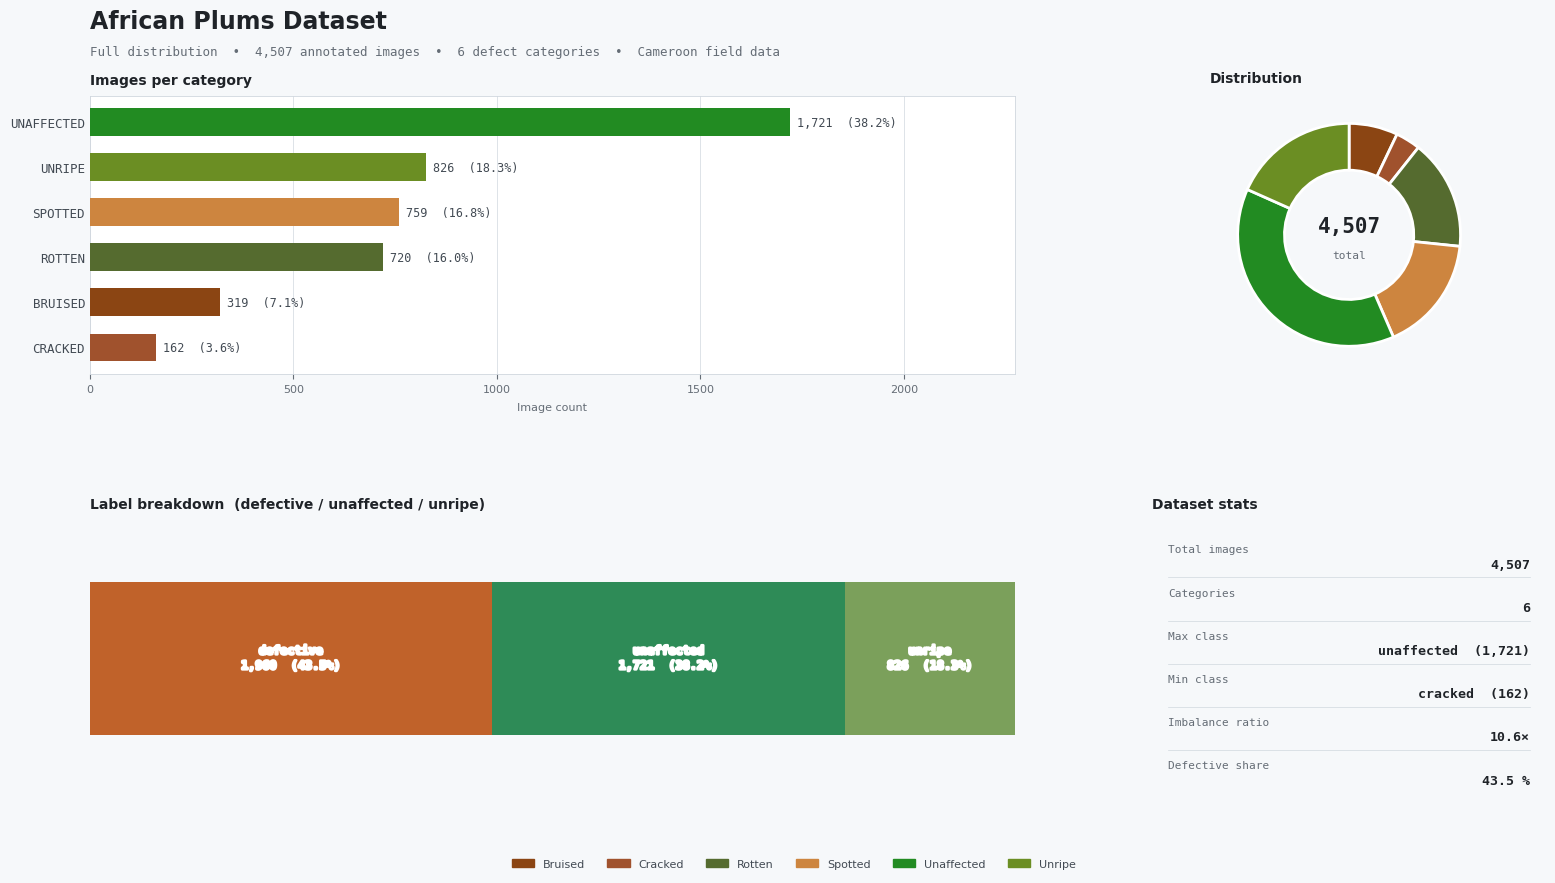

In [8]:
# dark theme (default), saves to PNG
plot_dataset_distribution(full_dataset, save_path="distribution.png", dpi=160, dark=False);

## 3. Model Architecture — Defining and Customizing the Neural Network

In this section, we design and customize several state-of-the-art deep learning architectures for computer vision tasks in order to solve our problem effectively. We explore a wide range of convolutional neural networks (CNNs), transformers, multimodal models, generative models, and diffusion-based architectures. Each model offers unique advantages in terms of accuracy, computational efficiency, scalability, and feature representation.

Below is a summary of the main architectures considered in this work.

---

### 1. AlexNet
- One of the first deep convolutional neural networks that achieved breakthrough performance in image classification.
- Introduced deep CNNs to large-scale computer vision tasks.
- Uses convolutional layers, ReLU activation, max pooling, and dropout.

---

### 2. ResNet (ResNet-50 / 101 / 152)
- Residual Neural Networks introduced residual connections (skip connections).
- Helps train very deep neural networks without suffering from vanishing gradients.
- Widely used in image classification, detection, and segmentation tasks.

---

### 3. GoogLeNet / Inception
- Uses Inception modules that process multiple convolution sizes in parallel.
- Improves computational efficiency while increasing network depth.
- Designed to capture multi-scale visual features effectively.

---

### 4. MobileNet (v1 / v2 / v3)
- Lightweight CNN architecture optimized for mobile and embedded devices.
- Uses depthwise separable convolutions to reduce computation.
- Provides a good balance between speed and accuracy.

---

### 5. EfficientNet (B0–B7)
- Scales network depth, width, and resolution using compound scaling.
- Achieves high accuracy with fewer parameters compared to traditional CNNs.
- Efficient for both research and deployment applications.

---

### 6. ShuffleNet
- Extremely lightweight architecture designed for low-power devices.
- Uses channel shuffling and grouped convolutions to improve efficiency.
- Suitable for real-time computer vision applications.

---

### 7. SqueezeNet
- Compact CNN architecture with very few parameters.
- Achieves AlexNet-level accuracy with significantly smaller model size.
- Useful for memory-constrained environments.

---

### 8. Vision Transformer (ViT)
- Applies transformer architecture directly to image patches.
- Captures long-range dependencies better than traditional CNNs.
- Performs exceptionally well on large-scale datasets.

---

### 9. Swin Transformer
- Hierarchical vision transformer using shifted windows.
- Efficient for dense prediction tasks such as segmentation and detection.
- Combines transformer flexibility with CNN-like scalability.

---

### 10. DeiT — Data-efficient Image Transformer
- A data-efficient variant of Vision Transformer.
- Uses knowledge distillation to improve performance with smaller datasets.
- Reduces training cost while maintaining strong accuracy.

---

### 11. ConvNeXt (v1 / v2)
- Modernized convolutional network inspired by transformers.
- Combines CNN efficiency with transformer design principles.
- Delivers competitive performance on vision benchmarks.

---

### 12. CLIP
- Multimodal model developed by OpenAI.
- Learns relationships between images and text descriptions.
- Enables zero-shot image classification and cross-modal understanding.

---

### 13. Grounding DINO
- Advanced object detection model guided by textual prompts.
- Combines grounding and detection capabilities.
- Useful for open-vocabulary object detection tasks.

---

### 14. ALIGN / Florence / SigLIP
- Large-scale vision-language models.
- Learn semantic relationships between text and images.
- Designed for image retrieval, captioning, and multimodal understanding.

---

### 15. BLIP / BLIP-2
- Vision-language models specialized for image captioning and reasoning.
- Combine visual encoders with large language models.
- Effective for multimodal AI applications.

---

### 16. GAN / StyleGAN / BigGAN
- Generative Adversarial Networks used for realistic image generation.
- StyleGAN produces high-quality controllable synthetic images.
- BigGAN improves large-scale image synthesis quality.

---

### 17. VAE — Variational Autoencoder
- Probabilistic generative model for image reconstruction and synthesis.
- Learns compact latent representations of data.
- Commonly used in unsupervised learning tasks.

---

### 18. VQ-VAE / DALL·E v1
- Vector Quantized VAE combines discrete latent representations with generation.
- Forms the foundation of early image generation systems such as DALL·E.
- Enables text-to-image synthesis.

---

### 19. Diffusion Models (DDPM / DDIM)
- Generative models based on progressive denoising.
- Produce highly realistic synthetic images.
- DDIM improves faster sampling compared to DDPM.

---

### 20. Latent Diffusion / Stable Diffusion
- Performs diffusion in latent feature space instead of pixel space.
- Reduces computational cost while maintaining image quality.
- Stable Diffusion became widely used for text-to-image generation.

---

### 21. DiT — Diffusion Transformer / Flux / Sora
- Combines diffusion modeling with transformer architectures.
- Designed for advanced image and video generation tasks.
- Sora extends these ideas to realistic video synthesis.

---

### Conclusion
The exploration of these architectures allows us to compare traditional CNN-based methods, transformer-based approaches, multimodal systems, and modern generative AI models. By evaluating their strengths and limitations, we can select the most suitable architecture for our computer vision problem based on accuracy, efficiency, scalability, and application requirements.

In [9]:
import os
import time
import copy

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    confusion_matrix, classification_report,
)

# ── Jupyter display fix: prevent double-render ─────────────────
%matplotlib inline
plt.rcParams["figure.max_open_warning"] = 0

In [10]:
# ─────────────────────────────────────────────────────────────
# Visual theme — change dark=False for a light theme
# ─────────────────────────────────────────────────────────────
_DARK = dict(
    BG       = "#0F1117",
    PANEL    = "#161B22",
    BORDER   = "#30363D",
    TEXT_PRI = "#E6EDF3",
    TEXT_SEC = "#8B949E",
    TEXT_MID = "#C9D1D9",
)
_LIGHT = dict(
    BG       = "#F6F8FA",
    PANEL    = "#FFFFFF",
    BORDER   = "#D0D7DE",
    TEXT_PRI = "#1F2328",
    TEXT_SEC = "#656D76",
    TEXT_MID = "#424A53",
)

ACC_COLOR  = "#2E8B57"   # green — accuracy curves
LOSS_COLOR = "#C0622A"   # orange — loss curves
CM_COLORS  = ["#0F1117", "#2E8B57"]   # dark → green colormap

In [10]:
def _plot_curves(
    history: dict,
    title_prefix: str = "",
    dark: bool = True,
    save_dir: str = ".",
) -> None:
    """
    Plot and save training/validation loss and accuracy curves.

    Parameters
    ----------
    history      : dict with keys train_loss, val_loss,
                   train_acc, val_acc  (lists of floats, one per epoch)
    title_prefix : prepended to each subplot title and the saved filename
    dark         : dark (True) or light (False) theme
    save_dir     : directory where the PNG is written
    """
    th = _DARK if dark else _LIGHT
    BG, PANEL, BORDER = th["BG"], th["PANEL"], th["BORDER"]
    TEXT_PRI, TEXT_SEC, TEXT_MID = th["TEXT_PRI"], th["TEXT_SEC"], th["TEXT_MID"]

    epochs = np.arange(1, len(history["train_loss"]) + 1)
    panels = [
        ("Loss",     "train_loss", "val_loss", LOSS_COLOR),
        ("Accuracy", "train_acc",  "val_acc",  ACC_COLOR),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)
    fig.patch.set_facecolor(BG)

    for ax, (metric, tr_key, vl_key, col) in zip(axes, panels):
        tr = np.array(history[tr_key])
        vl = np.array(history[vl_key])

        ax.set_facecolor(PANEL)
        for sp in ax.spines.values():
            sp.set_edgecolor(BORDER); sp.set_linewidth(0.6)

        ax.plot(epochs, tr, color=col, lw=2.2, label="Train", zorder=3)
        ax.plot(epochs, vl, color=col, lw=2.2, label="Val",
                dashes=(5, 3), alpha=0.80, zorder=3)
        ax.fill_between(epochs, tr, vl, alpha=0.08, color=col)

        # mark best validation epoch
        best = int(np.argmin(vl) if metric == "Loss" else np.argmax(vl))
        ax.axvline(epochs[best], color=col, alpha=0.35, lw=1, linestyle=":")
        ax.scatter(epochs[best], vl[best], color=col, s=60, zorder=5,
                   edgecolors=PANEL, linewidths=1.5,
                   label=f"Best val ({vl[best]:.4f})")

        ax.set_xlabel("Epoch", fontsize=9, color=TEXT_SEC)
        ax.set_title(
            f"{title_prefix}Training vs Validation {metric}",
            fontsize=11, color=TEXT_PRI, fontweight="bold", loc="left", pad=8,
        )
        ax.tick_params(colors=TEXT_SEC, labelsize=8)
        ax.xaxis.grid(True, color=BORDER, lw=0.4, zorder=0)
        ax.yaxis.grid(True, color=BORDER, lw=0.4, zorder=0)
        ax.set_axisbelow(True)
        ax.legend(fontsize=9, frameon=False, labelcolor=TEXT_MID)
        ax.set_xlim(epochs[0], epochs[-1])

    fig.suptitle(
        f"{title_prefix}Training Curves",
        fontsize=14, fontweight="bold", color=TEXT_PRI, y=1.02,
    )
    plt.tight_layout()

    fname = os.path.join(save_dir, f"{title_prefix}training_curves.png"
                         .replace(" ", "_").lower())
    fig.savefig(fname, dpi=150, bbox_inches="tight", facecolor=BG)
    print(f"✅  Curves saved → {fname}")
    plt.show()
    plt.close(fig)

In [11]:
def _plot_confusion_matrix(
    y_true,
    y_pred,
    class_names: list[str],
    title_prefix: str = "",
    dark: bool = True,
    save_dir: str = ".",
) -> None:
    """
    Plot and save an annotated confusion matrix (count + row %).

    Parameters
    ----------
    y_true       : ground-truth integer labels (array-like)
    y_pred       : predicted integer labels (array-like)
    class_names  : ordered list of class name strings
    title_prefix : prepended to the title and the saved filename
    dark         : dark (True) or light (False) theme
    save_dir     : directory where the PNG is written
    """
    th = _DARK if dark else _LIGHT
    BG, PANEL, BORDER = th["BG"], th["PANEL"], th["BORDER"]
    TEXT_PRI, TEXT_SEC, TEXT_MID = th["TEXT_PRI"], th["TEXT_SEC"], th["TEXT_MID"]

    cm   = confusion_matrix(y_true, y_pred)
    n_cl = len(class_names)
    cmap = LinearSegmentedColormap.from_list("plum_cm", CM_COLORS, N=256)

    fig, ax = plt.subplots(figsize=(max(8, n_cl * 1.4), max(6, n_cl * 1.1)),
                           facecolor=BG)
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(PANEL)

    im = ax.imshow(cm, cmap=cmap, aspect="auto")
    cb = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cb.ax.tick_params(colors=TEXT_SEC, labelsize=8)
    cb.outline.set_edgecolor(BORDER)

    for i in range(n_cl):
        for j in range(n_cl):
            v   = cm[i, j]
            tot = cm[i].sum()
            pct = v / tot * 100 if tot > 0 else 0.0
            brightness = v / (cm.max() or 1)
            fc = TEXT_PRI if brightness < 0.55 else "#0F1117"
            ax.text(j, i,       f"{v}",
                    ha="center", va="center", fontsize=9,
                    color=fc, fontweight="bold", fontfamily="monospace")
            ax.text(j, i + 0.3, f"{pct:.0f}%",
                    ha="center", va="center", fontsize=6.5,
                    color=fc, alpha=0.75, fontfamily="monospace")

    ax.set_xticks(range(n_cl))
    ax.set_yticks(range(n_cl))
    ax.set_xticklabels(
        [c.capitalize() for c in class_names],
        rotation=30, ha="right", fontsize=9, color=TEXT_MID,
    )
    ax.set_yticklabels(
        [c.capitalize() for c in class_names],
        fontsize=9, color=TEXT_MID,
    )
    ax.set_xlabel("Predicted label", fontsize=10, color=TEXT_SEC, labelpad=8)
    ax.set_ylabel("True label",      fontsize=10, color=TEXT_SEC, labelpad=8)
    ax.set_title(
        f"{title_prefix}Confusion Matrix",
        fontsize=13, color=TEXT_PRI, fontweight="bold", loc="left", pad=12,
    )
    for sp in ax.spines.values():
        sp.set_edgecolor(BORDER); sp.set_linewidth(0.6)
    ax.tick_params(length=0)

    plt.tight_layout()
    fname = os.path.join(save_dir, f"{title_prefix}confusion_matrix.png"
                         .replace(" ", "_").lower())
    fig.savefig(fname, dpi=150, bbox_inches="tight", facecolor=BG)
    print(f"✅  Confusion matrix saved → {fname}")
    plt.show()
    plt.close(fig)

In [12]:
def _print_metrics(
    y_true,
    y_pred,
    class_names: list[str],
    model_name: str = "Model",
) -> dict:
    """
    Print accuracy, precision, recall, F1 (macro & weighted)
    and a per-class classification report.

    Returns a dict with all scalar metrics.
    """
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec  = recall_score   (y_true, y_pred, average="weighted", zero_division=0)
    f1w  = f1_score       (y_true, y_pred, average="weighted", zero_division=0)
    f1m  = f1_score       (y_true, y_pred, average="macro",    zero_division=0)

    sep = "─" * 52
    print(f"\n{'':>4}{sep}")
    print(f"{'':>4}  📊  {model_name} — Evaluation Metrics")
    print(f"{'':>4}{sep}")
    print(f"{'':>4}  {'Accuracy':<22} {acc :.4f}  ({acc *100:.2f} %)")
    print(f"{'':>4}  {'Precision (weighted)':<22} {prec:.4f}")
    print(f"{'':>4}  {'Recall (weighted)':<22} {rec :.4f}")
    print(f"{'':>4}  {'F1 Score (weighted)':<22} {f1w :.4f}")
    print(f"{'':>4}  {'F1 Score (macro)':<22} {f1m :.4f}")
    print(f"{'':>4}{sep}")
    print()
    print(classification_report(
        y_true, y_pred,
        target_names=[c.capitalize() for c in class_names],
        zero_division=0,
    ))

    return dict(accuracy=acc, precision=prec, recall=rec,
                f1_weighted=f1w, f1_macro=f1m)

In [13]:
def train_and_evaluate(
    model:         nn.Module,
    train_loader:  DataLoader,
    val_loader:    DataLoader,
    class_names:   list[str],
    # ── optimisation ──────────────────────────────────────────
    criterion      = None,          # default: CrossEntropyLoss
    optimizer      = None,          # default: Adam lr=1e-3
    scheduler      = None,          # optional LR scheduler
    num_epochs:    int   = 25,
    # ── early stopping ────────────────────────────────────────
    patience:      int   = 5,       # 0 = disabled
    # ── checkpointing ─────────────────────────────────────────
    save_best:     bool  = True,    # save best-val-acc weights
    checkpoint_path: str = "best_model.pth",
    # ── output ────────────────────────────────────────────────
    model_name:    str   = "Model",
    save_dir:      str   = ".",
    dark:          bool  = True,
) -> dict:
    """
    Train and evaluate any PyTorch classification model.

    Parameters
    ----------
    model            : nn.Module — must output raw logits of shape (B, n_classes)
    train_loader     : DataLoader for the training split
    val_loader       : DataLoader for the validation split
    class_names      : ordered list of class name strings (len == n_classes)
    criterion        : loss function (default CrossEntropyLoss)
    optimizer        : optimiser (default Adam, lr=1e-3)
    scheduler        : optional LR scheduler called each epoch
    num_epochs       : maximum number of training epochs
    patience         : early-stopping patience (0 = disabled)
    save_best        : save the checkpoint with the best validation accuracy
    checkpoint_path  : path for the best-model checkpoint
    model_name       : label used in titles and printed reports
    save_dir         : directory to write all output PNGs
    dark             : dark (True) or light (False) plot theme

    Returns
    -------
    dict with keys:
        history    – per-epoch train/val loss & accuracy
        metrics    – final accuracy, precision, recall, F1
        best_epoch – epoch index (1-based) of best val accuracy
    """
    os.makedirs(save_dir, exist_ok=True)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🖥️   Device : {device}")
    model  = model.to(device)

    # ── defaults ──────────────────────────────────────────────
    if criterion is None:
        criterion = nn.CrossEntropyLoss()
    if optimizer is None:
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    # ── state ─────────────────────────────────────────────────
    history = dict(train_loss=[], val_loss=[],
                   train_acc=[], val_acc=[])
    best_val_acc   = 0.0
    best_weights   = copy.deepcopy(model.state_dict())
    best_epoch     = 1
    no_improve     = 0

    print(f"\n🚀  Training  {model_name}  for up to {num_epochs} epochs …")
    print(f"    Early stopping patience : {patience if patience > 0 else 'disabled'}")
    print(f"    Save best checkpoint   : {save_best} → {checkpoint_path}")
    print()

    total_start = time.time()

    for epoch in range(1, num_epochs + 1):
        ep_start = time.time()

        # ── TRAIN ─────────────────────────────────────────────
        model.train()
        tr_loss, tr_correct, tr_total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            tr_loss    += loss.item() * inputs.size(0)
            preds       = outputs.argmax(dim=1)
            tr_correct += (preds == labels).sum().item()
            tr_total   += inputs.size(0)

        tr_loss /= tr_total
        tr_acc   = tr_correct / tr_total

        # ── VALIDATE ──────────────────────────────────────────
        model.eval()
        vl_loss, vl_correct, vl_total = 0.0, 0, 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss    = criterion(outputs, labels)
                vl_loss    += loss.item() * inputs.size(0)
                preds       = outputs.argmax(dim=1)
                vl_correct += (preds == labels).sum().item()
                vl_total   += inputs.size(0)

        vl_loss /= vl_total
        vl_acc   = vl_correct / vl_total

        # ── record ────────────────────────────────────────────
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)

        if scheduler is not None:
            scheduler.step()

        ep_time = time.time() - ep_start
        print(
            f"  Epoch [{epoch:>3}/{num_epochs}]  "
            f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f}  │  "
            f"Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}  "
            f"({ep_time:.1f}s)"
        )

        # ── checkpoint ────────────────────────────────────────
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_weights = copy.deepcopy(model.state_dict())
            best_epoch   = epoch
            no_improve   = 0
            if save_best:
                torch.save(best_weights, checkpoint_path)
                print(f"    💾  New best val acc {best_val_acc:.4f} — checkpoint saved")
        else:
            no_improve += 1

        # ── early stopping ────────────────────────────────────
        if patience > 0 and no_improve >= patience:
            print(f"\n⏹️   Early stopping at epoch {epoch} "
                  f"(no improvement for {patience} epochs)")
            break

    total_time = time.time() - total_start
    print(f"\n✅  Training complete in {total_time/60:.1f} min")
    print(f"    Best val accuracy : {best_val_acc:.4f}  (epoch {best_epoch})")

    # restore best weights before evaluation
    model.load_state_dict(best_weights)

    # ── FULL VALIDATION PASS for metrics ──────────────────────
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            preds  = model(inputs).argmax(dim=1).cpu()
            all_preds.extend(preds.numpy())
            all_labels.extend(labels.numpy())

    # ── print metrics ─────────────────────────────────────────
    prefix = f"{model_name} — " if model_name else ""
    metrics = _print_metrics(all_labels, all_preds, class_names, model_name)

    # ── plot curves ───────────────────────────────────────────
    _plot_curves(history, title_prefix=prefix, dark=dark, save_dir=save_dir)

    # ── plot confusion matrix ─────────────────────────────────
    _plot_confusion_matrix(
        all_labels, all_preds, class_names,
        title_prefix=prefix, dark=dark, save_dir=save_dir,
    )

    return dict(history=history, metrics=metrics, best_epoch=best_epoch)

🖥️   Device : cpu

🚀  Training  EfficientNet-B0  for up to 30 epochs …
    Early stopping patience : 5
    Save best checkpoint   : True → best_efficientnet_bo.pth

  Epoch [  1/30]  Train Loss: 1.5140  Acc: 0.4354  │  Val Loss: 1.3620  Acc: 0.4970  (448.9s)
    💾  New best val acc 0.4970 — checkpoint saved
  Epoch [  2/30]  Train Loss: 1.3376  Acc: 0.5014  │  Val Loss: 1.2220  Acc: 0.5636  (458.4s)
    💾  New best val acc 0.5636 — checkpoint saved
  Epoch [  3/30]  Train Loss: 1.2528  Acc: 0.5489  │  Val Loss: 1.1896  Acc: 0.5917  (406.7s)
    💾  New best val acc 0.5917 — checkpoint saved
  Epoch [  4/30]  Train Loss: 1.1998  Acc: 0.5677  │  Val Loss: 1.1265  Acc: 0.5976  (415.3s)
    💾  New best val acc 0.5976 — checkpoint saved
  Epoch [  5/30]  Train Loss: 1.1744  Acc: 0.5701  │  Val Loss: 1.1252  Acc: 0.6139  (405.4s)
    💾  New best val acc 0.6139 — checkpoint saved
  Epoch [  6/30]  Train Loss: 1.1382  Acc: 0.5894  │  Val Loss: 1.0627  Acc: 0.5991  (399.6s)
  Epoch [  7/30]  Tra

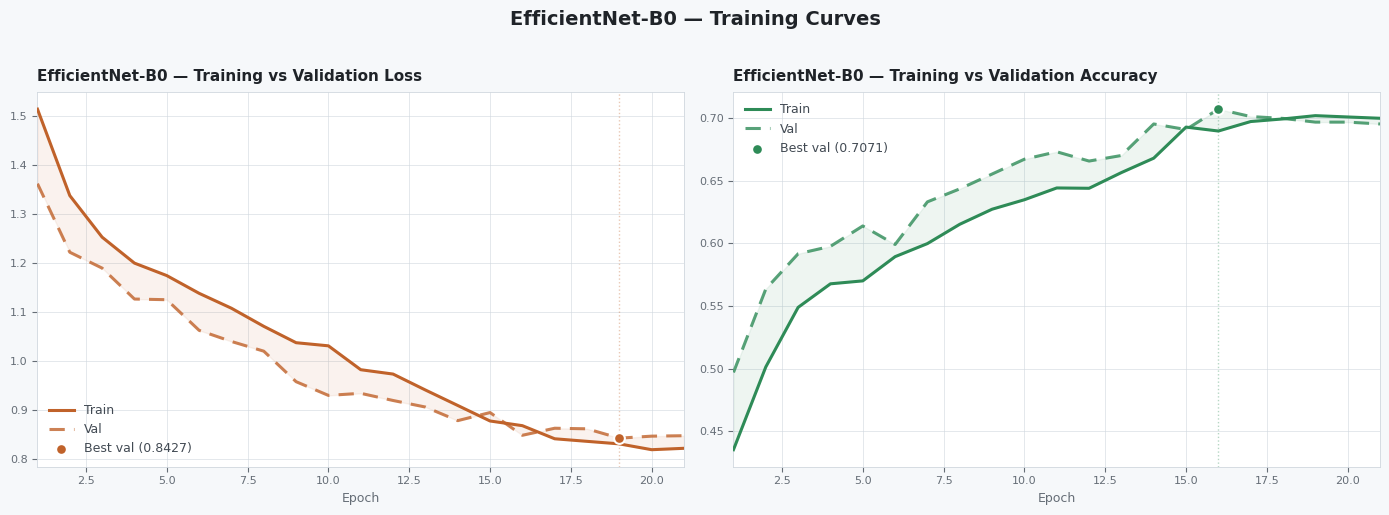

✅  Confusion matrix saved → outputs/efficientnet-b0_—_confusion_matrix.png


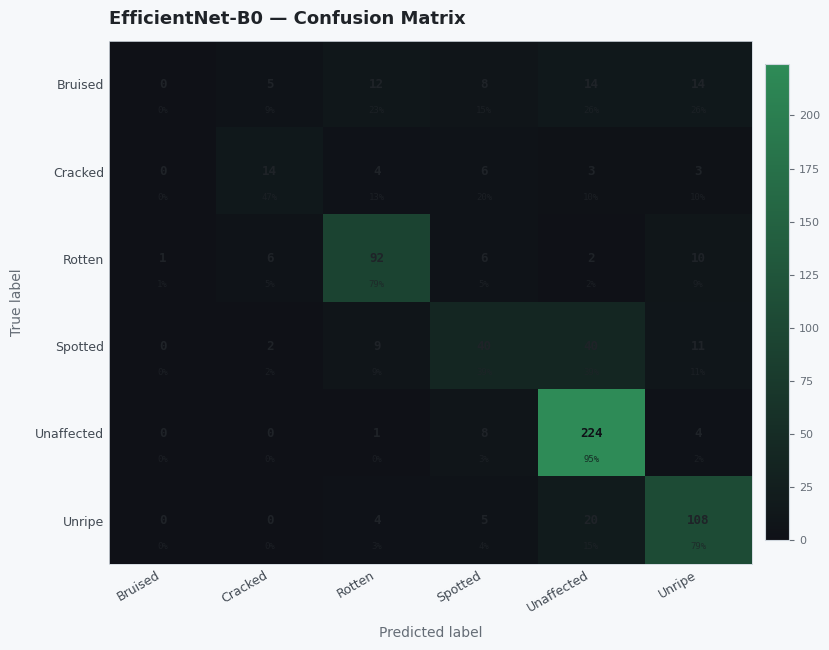

{'accuracy': 0.7071005917159763, 'precision': 0.6413067980817458, 'recall': 0.7071005917159763, 'f1_weighted': 0.6674126679006959, 'f1_macro': 0.5500813790589153}
16
{'train_loss': [1.514038021214106, 1.3376279079207736, 1.2527839845292905, 1.1998417175833658, 1.174390478844868, 1.1382194428243515, 1.107762125104129, 1.0708534702312476, 1.037433201231741, 1.0310567799450927, 0.9823210516351846, 0.9734358730281311, 0.9409363712756635, 0.9093781928423645, 0.8776888066936305, 0.8681363778461585, 0.8414058579349294, 0.8361555491001604, 0.8309793709246118, 0.8191100214735642, 0.821938162713784], 'val_loss': [1.3619573342024223, 1.2220234609919893, 1.1896204969586706, 1.1265377342348268, 1.1251502308619798, 1.062671351009572, 1.0399438065184643, 1.0201539513627453, 0.9578971245585108, 0.9298873067607542, 0.9341421936743358, 0.9195268425715746, 0.9061484174615533, 0.8783826856218147, 0.8948959154490184, 0.8485208157251573, 0.8628902456464147, 0.8617323940322243, 0.8426530026119842, 0.84675939

In [15]:
# 1. Build / import your model
from torchvision.models import efficientnet_b0
model = efficientnet_b0(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 6)

# 2. (Optional) custom loss / optimiser / scheduler
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

# 3. Call the function
results = train_and_evaluate(
    model         = model,
    train_loader  = train_loader,      # from african_plums_loader.py
    val_loader    = val_loader,
    class_names   = AfricanPlumsDataset.CATEGORIES,
    criterion     = criterion,
    optimizer     = optimizer,
    scheduler     = scheduler,
    num_epochs    = 30,
    patience      = 5,
    save_best     = True,
    checkpoint_path = "best_efficientnet_bo.pth",
    model_name    = "EfficientNet-B0",
    save_dir      = "outputs/",
    dark          = False,
)

# 4. Inspect results
print(results["metrics"])       # dict: accuracy, precision, recall, f1_*
print(results["best_epoch"])    # int
print(results["history"])       # dict of lists for custom plotting

🖥️   Device : cpu

🚀  Training  EfficientNet-B1  for up to 30 epochs …
    Early stopping patience : 5
    Save best checkpoint   : True → best_efficientnet_b1.pth

  Epoch [  1/30]  Train Loss: 1.6099  Acc: 0.3942  │  Val Loss: 1.5283  Acc: 0.4364  (846.8s)
    💾  New best val acc 0.4364 — checkpoint saved
  Epoch [  2/30]  Train Loss: 1.4446  Acc: 0.4599  │  Val Loss: 1.3331  Acc: 0.5207  (693.9s)
    💾  New best val acc 0.5207 — checkpoint saved
  Epoch [  3/30]  Train Loss: 1.3446  Acc: 0.5095  │  Val Loss: 1.2709  Acc: 0.5562  (486.2s)
    💾  New best val acc 0.5562 — checkpoint saved
  Epoch [  4/30]  Train Loss: 1.2829  Acc: 0.5364  │  Val Loss: 1.1706  Acc: 0.5814  (491.7s)
    💾  New best val acc 0.5814 — checkpoint saved
  Epoch [  5/30]  Train Loss: 1.2304  Acc: 0.5604  │  Val Loss: 1.1359  Acc: 0.6124  (32427.7s)
    💾  New best val acc 0.6124 — checkpoint saved
  Epoch [  6/30]  Train Loss: 1.2160  Acc: 0.5688  │  Val Loss: 1.0954  Acc: 0.6169  (545.6s)
    💾  New best val

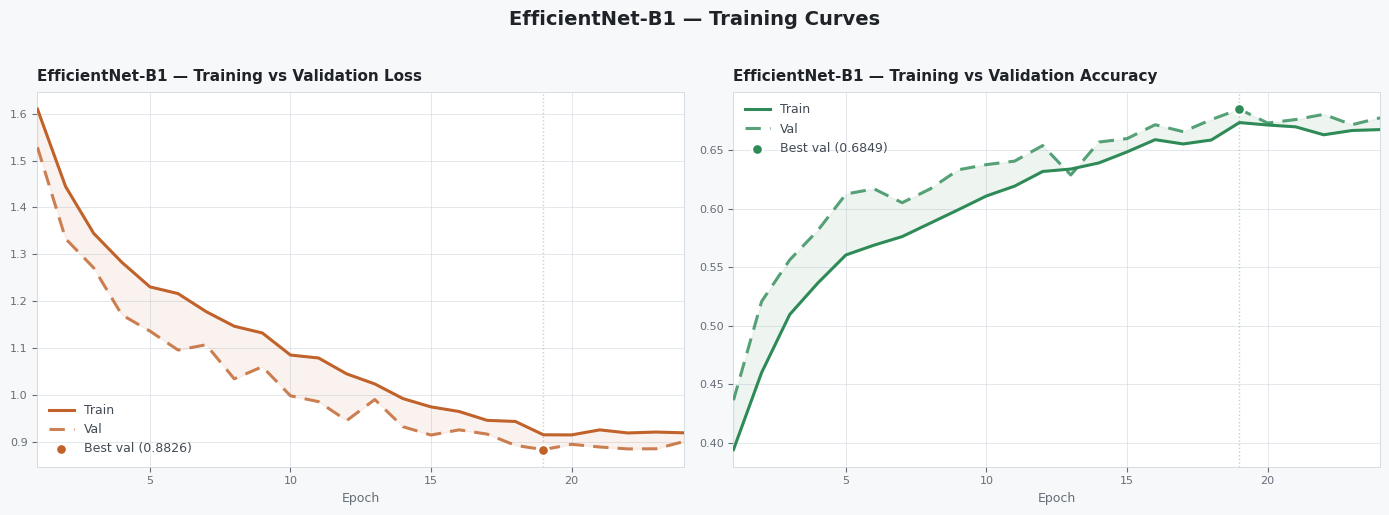

✅  Confusion matrix saved → outputs/efficientnet-b1_—_confusion_matrix.png


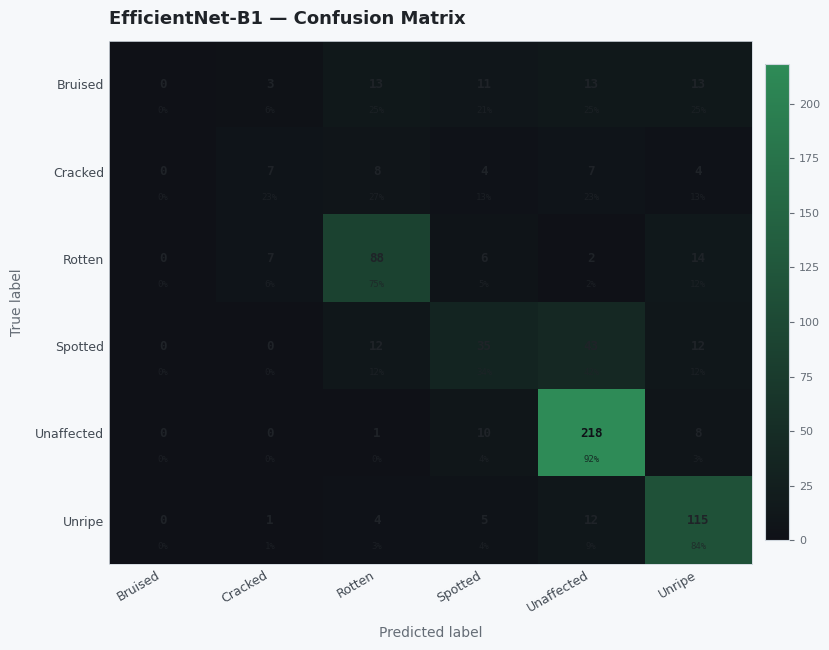

{'accuracy': 0.6849112426035503, 'precision': 0.611998911430269, 'recall': 0.6849112426035503, 'f1_weighted': 0.6405161229112717, 'f1_macro': 0.4998659265475785}
19
{'train_loss': [1.6098520664283795, 1.444641936575268, 1.3445584892261997, 1.282858373259353, 1.2303597335714611, 1.2159798323127937, 1.1774680695686848, 1.1462867468463258, 1.1318442781984075, 1.0847441038616144, 1.0784406066407612, 1.0445444294504571, 1.0230250542327524, 0.9918162529601094, 0.9739885342180247, 0.9641854482977859, 0.9452593969912916, 0.9429240954572617, 0.9144394421073357, 0.9141745427917545, 0.9249597504692207, 0.9183750963186166, 0.9202905455198216, 0.9186599492030989], 'val_loss': [1.5283051757417487, 1.3331425070057255, 1.2708831990258933, 1.1705698035877836, 1.135875595744545, 1.0953835256000948, 1.10673936443216, 1.0339012794946072, 1.0598205052889311, 0.9976763407859577, 0.9852008579750738, 0.9447954138355142, 0.9897303362569866, 0.931709705725224, 0.9139088533333772, 0.924991712767697, 0.9158396163

In [16]:
# 1. Build / import your model
from torchvision.models import efficientnet_b1
model = efficientnet_b1(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 6)

# 2. (Optional) custom loss / optimiser / scheduler
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

# 3. Call the function
results = train_and_evaluate(
    model         = model,
    train_loader  = train_loader,      # from african_plums_loader.py
    val_loader    = val_loader,
    class_names   = AfricanPlumsDataset.CATEGORIES,
    criterion     = criterion,
    optimizer     = optimizer,
    scheduler     = scheduler,
    num_epochs    = 30,
    patience      = 5,
    save_best     = True,
    checkpoint_path = "best_efficientnet_b1.pth",
    model_name    = "EfficientNet-B1",
    save_dir      = "outputs/",
    dark          = False,
)

# 4. Inspect results
print(results["metrics"])       # dict: accuracy, precision, recall, f1_*
print(results["best_epoch"])    # int
print(results["history"])  

🖥️   Device : cpu

🚀  Training  EfficientNet-B2  for up to 30 epochs …
    Early stopping patience : 5
    Save best checkpoint   : True → best_efficientnet_b2.pth

  Epoch [  1/30]  Train Loss: 1.6027  Acc: 0.3895  │  Val Loss: 1.4995  Acc: 0.4275  (530.8s)
    💾  New best val acc 0.4275 — checkpoint saved
  Epoch [  2/30]  Train Loss: 1.4788  Acc: 0.4328  │  Val Loss: 1.3618  Acc: 0.4749  (559.4s)
    💾  New best val acc 0.4749 — checkpoint saved
  Epoch [  3/30]  Train Loss: 1.3808  Acc: 0.4759  │  Val Loss: 1.3127  Acc: 0.5444  (493.9s)
    💾  New best val acc 0.5444 — checkpoint saved
  Epoch [  4/30]  Train Loss: 1.3155  Acc: 0.5249  │  Val Loss: 1.2187  Acc: 0.5740  (21387.1s)
    💾  New best val acc 0.5740 — checkpoint saved
  Epoch [  5/30]  Train Loss: 1.2529  Acc: 0.5547  │  Val Loss: 1.2022  Acc: 0.5917  (493.0s)
    💾  New best val acc 0.5917 — checkpoint saved
  Epoch [  6/30]  Train Loss: 1.2055  Acc: 0.5638  │  Val Loss: 1.1602  Acc: 0.5902  (492.5s)
  Epoch [  7/30]  T

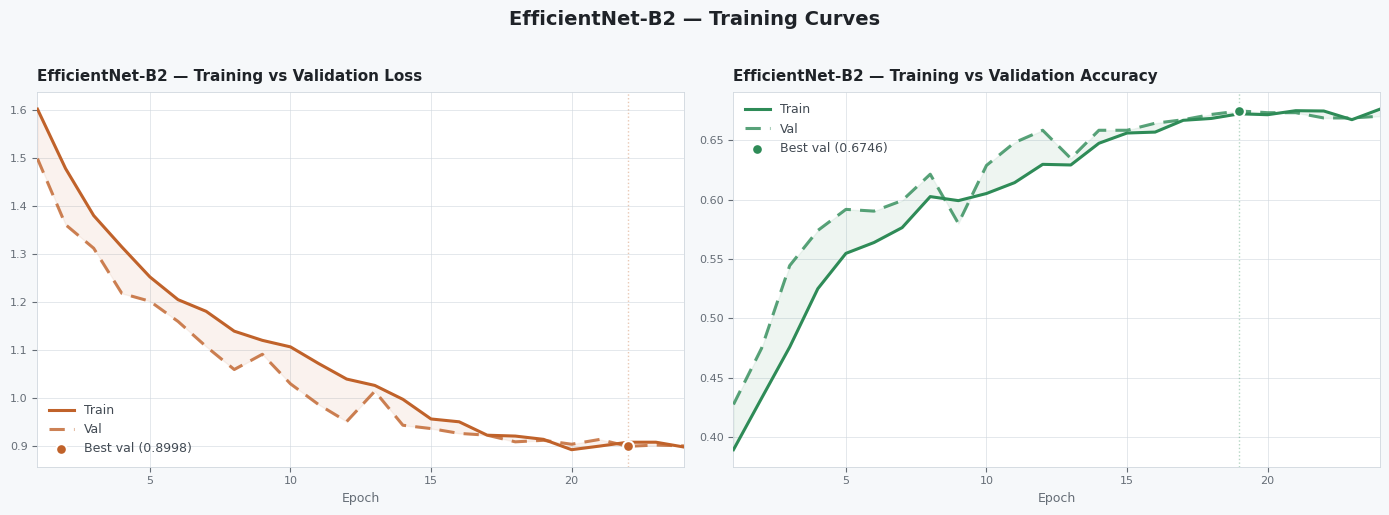

✅  Confusion matrix saved → outputs/efficientnet-b2_—_confusion_matrix.png


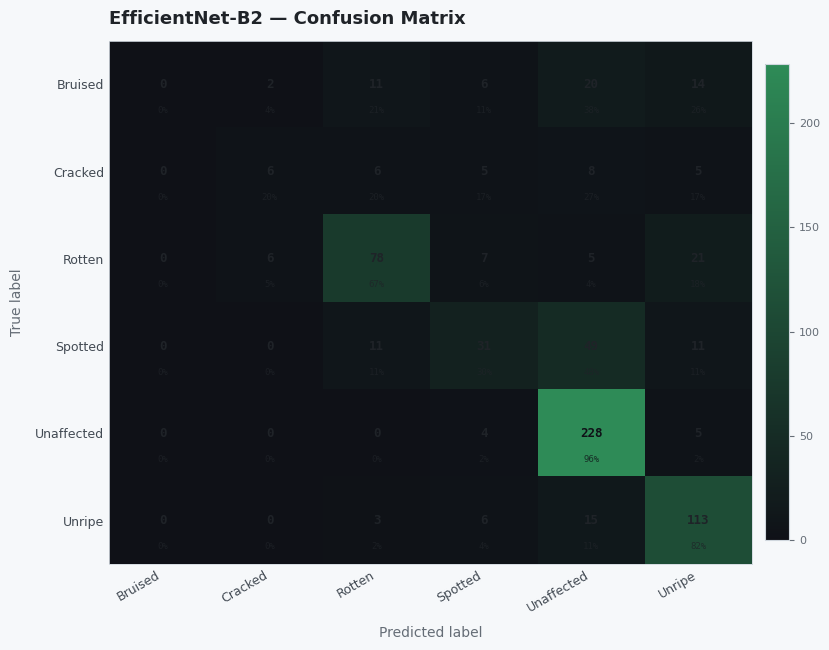

{'accuracy': 0.6745562130177515, 'precision': 0.6036143484005934, 'recall': 0.6745562130177515, 'f1_weighted': 0.6238229617671601, 'f1_macro': 0.4830059865023233}
19
{'train_loss': [1.6026978487758095, 1.4787989841432305, 1.3808413847592442, 1.3154789870602441, 1.2529126374287756, 1.2055346657108994, 1.1812309892860289, 1.1398417953410556, 1.1207056078827433, 1.1070868002157925, 1.072449517324742, 1.0399962093275603, 1.026731275167891, 0.997773106836893, 0.956818961888684, 0.9509359381740942, 0.922956444395021, 0.9211776073282053, 0.9143701522289944, 0.8927695362849821, 0.9003070793273834, 0.9083440464988635, 0.9084062226383097, 0.8983085185048226], 'val_loss': [1.499461118286178, 1.361797961962999, 1.3126990583521374, 1.2186716780860043, 1.2022112861892882, 1.1601582765579224, 1.1078868497758223, 1.0599199596946762, 1.091716130809671, 1.0300868291121263, 0.9868806755754369, 0.9514636104628884, 1.0146361321387207, 0.9437217952231683, 0.9368061793626413, 0.9267751585097003, 0.9229880169

In [17]:
# 1. Build / import your model
from torchvision.models import efficientnet_b2
model = efficientnet_b2(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 6)

# 2. (Optional) custom loss / optimiser / scheduler
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

# 3. Call the function
results = train_and_evaluate(
    model         = model,
    train_loader  = train_loader,      # from african_plums_loader.py
    val_loader    = val_loader,
    class_names   = AfricanPlumsDataset.CATEGORIES,
    criterion     = criterion,
    optimizer     = optimizer,
    scheduler     = scheduler,
    num_epochs    = 30,
    patience      = 5,
    save_best     = True,
    checkpoint_path = "best_efficientnet_b2.pth",
    model_name    = "EfficientNet-B2",
    save_dir      = "outputs/",
    dark          = False,
)

# 4. Inspect results
print(results["metrics"])       # dict: accuracy, precision, recall, f1_*
print(results["best_epoch"])    # int
print(results["history"])  

🖥️   Device : cpu

🚀  Training  EfficientNet-B3  for up to 30 epochs …
    Early stopping patience : 5
    Save best checkpoint   : True → best_efficientnet_b3.pth

  Epoch [  1/30]  Train Loss: 1.5797  Acc: 0.4067  │  Val Loss: 1.5000  Acc: 0.4749  (611.2s)
    💾  New best val acc 0.4749 — checkpoint saved
  Epoch [  2/30]  Train Loss: 1.4276  Acc: 0.4683  │  Val Loss: 1.2771  Acc: 0.5325  (964.4s)
    💾  New best val acc 0.5325 — checkpoint saved
  Epoch [  3/30]  Train Loss: 1.3391  Acc: 0.5106  │  Val Loss: 1.2773  Acc: 0.5429  (1145.9s)
    💾  New best val acc 0.5429 — checkpoint saved
  Epoch [  4/30]  Train Loss: 1.2852  Acc: 0.5348  │  Val Loss: 1.2557  Acc: 0.5399  (720.8s)
  Epoch [  5/30]  Train Loss: 1.2466  Acc: 0.5497  │  Val Loss: 1.1458  Acc: 0.5917  (625.9s)
    💾  New best val acc 0.5917 — checkpoint saved
  Epoch [  6/30]  Train Loss: 1.2033  Acc: 0.5683  │  Val Loss: 1.1365  Acc: 0.5843  (22285.5s)
  Epoch [  7/30]  Train Loss: 1.1504  Acc: 0.5871  │  Val Loss: 1.10

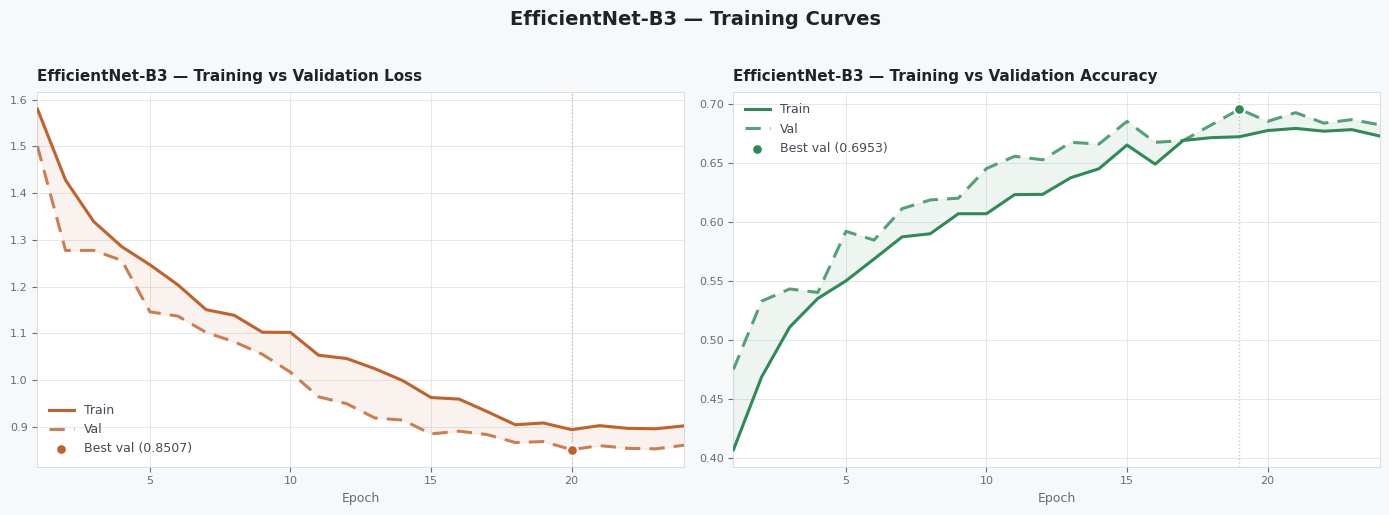

✅  Confusion matrix saved → outputs/efficientnet-b3_—_confusion_matrix.png


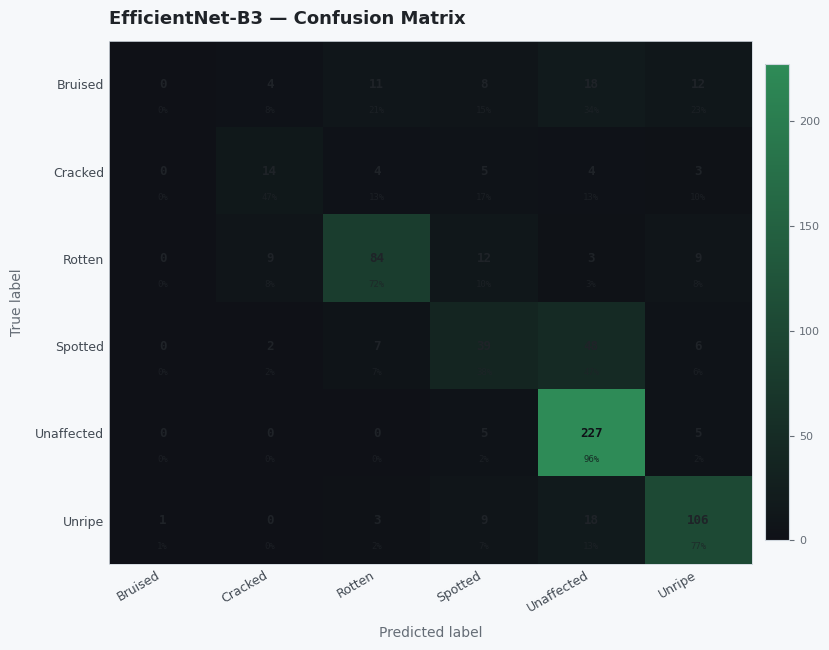

{'accuracy': 0.6952662721893491, 'precision': 0.6328698954434997, 'recall': 0.6952662721893491, 'f1_weighted': 0.6564435353212752, 'f1_macro': 0.5386467304089589}
19
{'train_loss': [1.5796858831224911, 1.427641204367478, 1.3390505538226978, 1.2852084316805306, 1.24655626866314, 1.2033151406838545, 1.1503870428713143, 1.1384411279167528, 1.1021329819984953, 1.1018179745003251, 1.052886218587153, 1.0458653041010144, 1.0241460741670907, 0.9983502953303324, 0.9623510114706643, 0.9589710219103684, 0.9322165784435028, 0.9040408624709041, 0.9078703876171496, 0.8936263362815566, 0.9021690944503848, 0.89638885456599, 0.895476307734532, 0.9017450784740731], 'val_loss': [1.4999837882420015, 1.277105445692525, 1.2773415054795305, 1.2557215944549742, 1.1457821652734068, 1.13653295350498, 1.10168057644861, 1.081744393300728, 1.0548531240260108, 1.016570856232615, 0.9639409702910474, 0.9491154350472625, 0.9186092636288976, 0.9140021053291637, 0.8845419009056317, 0.8902441587673842, 0.8830058412439019

In [18]:
# 1. Build / import your model
from torchvision.models import efficientnet_b3
model = efficientnet_b3(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 6)

# 2. (Optional) custom loss / optimiser / scheduler
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

# 3. Call the function
results = train_and_evaluate(
    model         = model,
    train_loader  = train_loader,      # from african_plums_loader.py
    val_loader    = val_loader,
    class_names   = AfricanPlumsDataset.CATEGORIES,
    criterion     = criterion,
    optimizer     = optimizer,
    scheduler     = scheduler,
    num_epochs    = 30,
    patience      = 5,
    save_best     = True,
    checkpoint_path = "best_efficientnet_b3.pth",
    model_name    = "EfficientNet-B3",
    save_dir      = "outputs/",
    dark          = False,
)

# 4. Inspect results
print(results["metrics"])       # dict: accuracy, precision, recall, f1_*
print(results["best_epoch"])    # int
print(results["history"]) 

In [ ]:
# 1. Build / import your model
from torchvision.models import efficientnet_b4
model = efficientnet_b4(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 6)

# 2. (Optional) custom loss / optimiser / scheduler
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

# 3. Call the function
results = train_and_evaluate(
    model         = model,
    train_loader  = train_loader,      # from african_plums_loader.py
    val_loader    = val_loader,
    class_names   = AfricanPlumsDataset.CATEGORIES,
    criterion     = criterion,
    optimizer     = optimizer,
    scheduler     = scheduler,
    num_epochs    = 30,
    patience      = 5,
    save_best     = True,
    checkpoint_path = "best_efficientnet_b4.pth",
    model_name    = "EfficientNet-B4",
    save_dir      = "outputs/",
    dark          = False,
)

# 4. Inspect results
print(results["metrics"])       # dict: accuracy, precision, recall, f1_*
print(results["best_epoch"])    # int
print(results["history"]) 

🖥️   Device : cpu

🚀  Training  EfficientNet-B4  for up to 30 epochs …
    Early stopping patience : 5
    Save best checkpoint   : True → best_efficientnet_b4.pth

  Epoch [  1/30]  Train Loss: 1.6187  Acc: 0.3939  │  Val Loss: 1.4728  Acc: 0.4334  (854.5s)
    💾  New best val acc 0.4334 — checkpoint saved
  Epoch [  2/30]  Train Loss: 1.4913  Acc: 0.4422  │  Val Loss: 1.3906  Acc: 0.4867  (1957.4s)
    💾  New best val acc 0.4867 — checkpoint saved


In [ ]:
# 1. Build / import your model
from torchvision.models import efficientnet_b5
model = efficientnet_b5(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 6)

# 2. (Optional) custom loss / optimiser / scheduler
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

# 3. Call the function
results = train_and_evaluate(
    model         = model,
    train_loader  = train_loader,      # from african_plums_loader.py
    val_loader    = val_loader,
    class_names   = AfricanPlumsDataset.CATEGORIES,
    criterion     = criterion,
    optimizer     = optimizer,
    scheduler     = scheduler,
    num_epochs    = 30,
    patience      = 5,
    save_best     = True,
    checkpoint_path = "best_efficientnet_b5.pth",
    model_name    = "EfficientNet-B5",
    save_dir      = "outputs/",
    dark          = False,
)

# 4. Inspect results
print(results["metrics"])       # dict: accuracy, precision, recall, f1_*
print(results["best_epoch"])    # int
print(results["history"]) 

In [ ]:
# 1. Build / import your model
from torchvision.models import efficientnet_b6
model = efficientnet_b6(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 6)

# 2. (Optional) custom loss / optimiser / scheduler
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

# 3. Call the function
results = train_and_evaluate(
    model         = model,
    train_loader  = train_loader,      # from african_plums_loader.py
    val_loader    = val_loader,
    class_names   = AfricanPlumsDataset.CATEGORIES,
    criterion     = criterion,
    optimizer     = optimizer,
    scheduler     = scheduler,
    num_epochs    = 30,
    patience      = 5,
    save_best     = True,
    checkpoint_path = "best_efficientnet_b6.pth",
    model_name    = "EfficientNet-B6",
    save_dir      = "outputs/",
    dark          = False,
)

# 4. Inspect results
print(results["metrics"])       # dict: accuracy, precision, recall, f1_*
print(results["best_epoch"])    # int
print(results["history"]) 

In [ ]:
# 1. Build / import your model
from torchvision.models import efficientnet_b7
model = efficientnet_b7(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 6)

# 2. (Optional) custom loss / optimiser / scheduler
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

# 3. Call the function
results = train_and_evaluate(
    model         = model,
    train_loader  = train_loader,      # from african_plums_loader.py
    val_loader    = val_loader,
    class_names   = AfricanPlumsDataset.CATEGORIES,
    criterion     = criterion,
    optimizer     = optimizer,
    scheduler     = scheduler,
    num_epochs    = 30,
    patience      = 5,
    save_best     = True,
    checkpoint_path = "best_efficientnet_b7.pth",
    model_name    = "EfficientNet-B7",
    save_dir      = "outputs/",
    dark          = False,
)

# 4. Inspect results
print(results["metrics"])       # dict: accuracy, precision, recall, f1_*
print(results["best_epoch"])    # int
print(results["history"]) 

In [ ]:
# 1. Build / import your model
from torchvision.models import efficientnet_v2_l
model = efficientnet_v2_l(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 6)

# 2. (Optional) custom loss / optimiser / scheduler
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

# 3. Call the function
results = train_and_evaluate(
    model         = model,
    train_loader  = train_loader,      # from african_plums_loader.py
    val_loader    = val_loader,
    class_names   = AfricanPlumsDataset.CATEGORIES,
    criterion     = criterion,
    optimizer     = optimizer,
    scheduler     = scheduler,
    num_epochs    = 30,
    patience      = 5,
    save_best     = True,
    checkpoint_path = "best_efficientnet_v2_l.pth",
    model_name    = "EfficientNet-V2_l",
    save_dir      = "outputs/",
    dark          = False,
)

# 4. Inspect results
print(results["metrics"])       # dict: accuracy, precision, recall, f1_*
print(results["best_epoch"])    # int
print(results["history"]) 

In [ ]:
# 1. Build / import your model
from torchvision.models import efficientnet_v2_m
model = efficientnet_v2_m(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 6)

# 2. (Optional) custom loss / optimiser / scheduler
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

# 3. Call the function
results = train_and_evaluate(
    model         = model,
    train_loader  = train_loader,      # from african_plums_loader.py
    val_loader    = val_loader,
    class_names   = AfricanPlumsDataset.CATEGORIES,
    criterion     = criterion,
    optimizer     = optimizer,
    scheduler     = scheduler,
    num_epochs    = 30,
    patience      = 5,
    save_best     = True,
    checkpoint_path = "best_efficientnet_v2_m.pth",
    model_name    = "EfficientNet-V2_m",
    save_dir      = "outputs/",
    dark          = False,
)

# 4. Inspect results
print(results["metrics"])       # dict: accuracy, precision, recall, f1_*
print(results["best_epoch"])    # int
print(results["history"]) 

In [ ]:
# 1. Build / import your model
from torchvision.models import efficientnet_v2_s
model = efficientnet_v2_s(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 6)

# 2. (Optional) custom loss / optimiser / scheduler
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

# 3. Call the function
results = train_and_evaluate(
    model         = model,
    train_loader  = train_loader,      # from african_plums_loader.py
    val_loader    = val_loader,
    class_names   = AfricanPlumsDataset.CATEGORIES,
    criterion     = criterion,
    optimizer     = optimizer,
    scheduler     = scheduler,
    num_epochs    = 30,
    patience      = 5,
    save_best     = True,
    checkpoint_path = "best_efficientnet_v2_s.pth",
    model_name    = "EfficientNet-V2_s",
    save_dir      = "outputs/",
    dark          = False,
)

# 4. Inspect results
print(results["metrics"])       # dict: accuracy, precision, recall, f1_*
print(results["best_epoch"])    # int
print(results["history"])

🖥️   Device : cpu

🚀  Training  AlexNet  for up to 30 epochs …
    Early stopping patience : 5
    Save best checkpoint   : True → best_alexnet.pth

  Epoch [  1/30]  Train Loss: 1.5378  Acc: 0.3892  │  Val Loss: 1.3794  Acc: 0.4645  (127.8s)
    💾  New best val acc 0.4645 — checkpoint saved
  Epoch [  2/30]  Train Loss: 1.3308  Acc: 0.5082  │  Val Loss: 1.2908  Acc: 0.5178  (125.9s)
    💾  New best val acc 0.5178 — checkpoint saved
  Epoch [  3/30]  Train Loss: 1.2930  Acc: 0.5354  │  Val Loss: 1.2415  Acc: 0.5459  (131.3s)
    💾  New best val acc 0.5459 — checkpoint saved
  Epoch [  4/30]  Train Loss: 1.2393  Acc: 0.5586  │  Val Loss: 1.2158  Acc: 0.5725  (118.6s)
    💾  New best val acc 0.5725 — checkpoint saved
  Epoch [  5/30]  Train Loss: 1.2093  Acc: 0.5688  │  Val Loss: 1.1859  Acc: 0.5843  (115.0s)
    💾  New best val acc 0.5843 — checkpoint saved
  Epoch [  6/30]  Train Loss: 1.1734  Acc: 0.5774  │  Val Loss: 1.1392  Acc: 0.5799  (117.5s)
  Epoch [  7/30]  Train Loss: 1.1574 

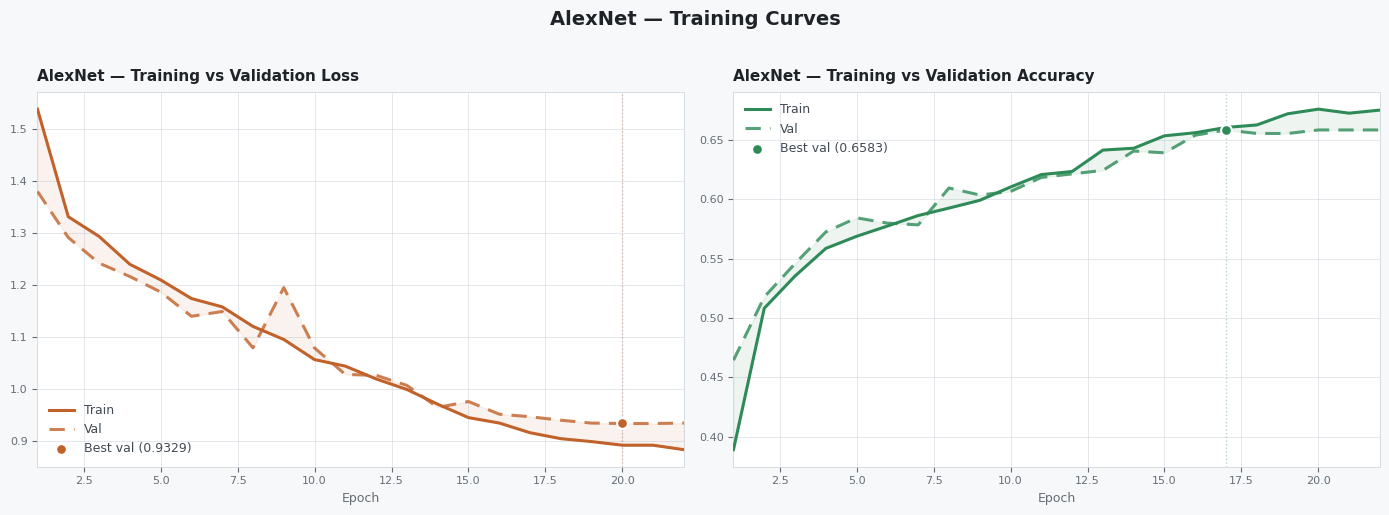

✅  Confusion matrix saved → outputs/alexnet_—_confusion_matrix.png


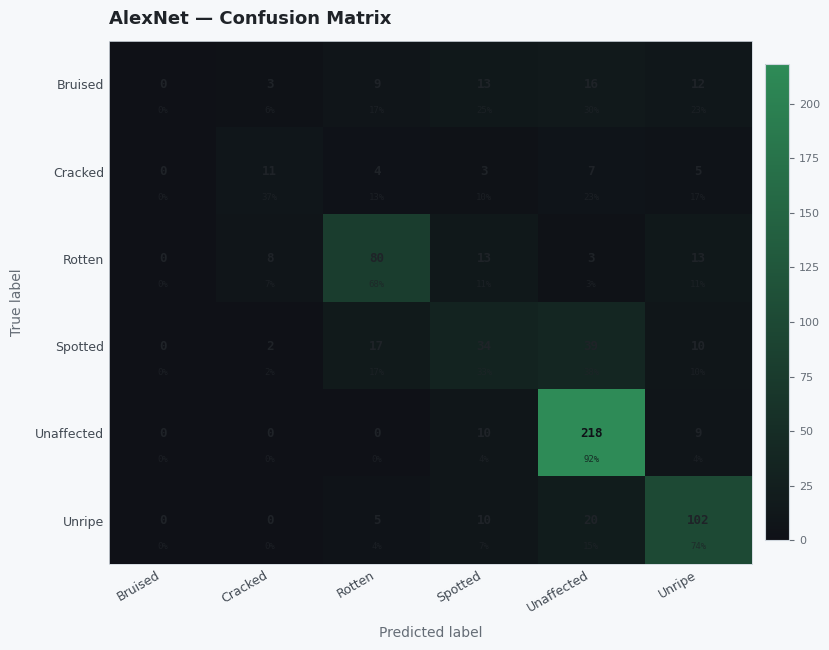

{'accuracy': 0.658284023668639, 'precision': 0.5916898442614068, 'recall': 0.658284023668639, 'f1_weighted': 0.6195280939478554, 'f1_macro': 0.4967284813549182}
17
{'train_loss': [1.5378119684143186, 1.3307918286827642, 1.292964669594532, 1.2393189869048982, 1.2092505815103203, 1.17340600751953, 1.1573832162644464, 1.1197292821832376, 1.0946165839021993, 1.0558517794327773, 1.043306636891207, 1.0186429435109632, 0.9983194819382917, 0.9700240410205061, 0.9442148633521023, 0.9338089665181641, 0.9151277325850994, 0.9036826712753467, 0.8980785948867369, 0.8911361100623266, 0.8911017670515653, 0.8824964462855067], 'val_loss': [1.3793898052012428, 1.290773877025356, 1.2414778661445753, 1.2157538141724626, 1.1858862095330593, 1.1392178126340786, 1.148388701077749, 1.078478092272606, 1.1944697883707531, 1.0781441292113807, 1.0272288604600894, 1.0256229293416943, 1.0062720493452084, 0.9637938843676325, 0.975189328899045, 0.9509004072324764, 0.9459678604757997, 0.9391965492237249, 0.933707498234

In [15]:
# ============================================================
# AlexNet
# ============================================================

# 1. Build / import your model
from torchvision.models import alexnet
import torch
import torch.nn as nn

model = alexnet(weights=None)

# Replace final classifier layer for 6 classes
model.classifier[6] = nn.Linear(model.classifier[6].in_features, 6)

# 2. (Optional) custom loss / optimiser / scheduler
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=20
)

# 3. Call the function
results = train_and_evaluate(
    model           = model,
    train_loader    = train_loader,      # from african_plums_loader.py
    val_loader      = val_loader,
    class_names     = AfricanPlumsDataset.CATEGORIES,
    criterion       = criterion,
    optimizer       = optimizer,
    scheduler       = scheduler,
    num_epochs      = 30,
    patience        = 5,
    save_best       = True,
    checkpoint_path = "best_alexnet.pth",
    model_name      = "AlexNet",
    save_dir        = "outputs/",
    dark            = False,
)

# 4. Inspect results
print(results["metrics"])       # dict: accuracy, precision, recall, f1_*
print(results["best_epoch"])    # int
print(results["history"])

In [ ]:
# ============================================================
# VGG16
# ============================================================

from torchvision.models import vgg16
import torch
import torch.nn as nn

model = vgg16(weights=None)
model.classifier[6] = nn.Linear(model.classifier[6].in_features, 6)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

results = train_and_evaluate(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    class_names=AfricanPlumsDataset.CATEGORIES,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=30,
    patience=5,
    save_best=True,
    checkpoint_path="best_vgg16.pth",
    model_name="VGG16",
    save_dir="outputs/",
    dark=False,
)

🖥️   Device : cpu

🚀  Training  VGG16  for up to 30 epochs …
    Early stopping patience : 5
    Save best checkpoint   : True → best_vgg16.pth



🖥️   Device : cpu

🚀  Training  VGG19  for up to 30 epochs …
    Early stopping patience : 5
    Save best checkpoint   : True → best_vgg19.pth

  Epoch [  1/30]  Train Loss: 1.6495  Acc: 0.3446  │  Val Loss: 1.6288  Acc: 0.3506  (2677.0s)
    💾  New best val acc 0.3506 — checkpoint saved
  Epoch [  2/30]  Train Loss: 1.5812  Acc: 0.3874  │  Val Loss: 1.6333  Acc: 0.3506  (2286.7s)
  Epoch [  3/30]  Train Loss: 1.5786  Acc: 0.3874  │  Val Loss: 1.6252  Acc: 0.3506  (1295.4s)
  Epoch [  4/30]  Train Loss: 1.5805  Acc: 0.3874  │  Val Loss: 1.6331  Acc: 0.3506  (3190.0s)
  Epoch [  5/30]  Train Loss: 1.5794  Acc: 0.3874  │  Val Loss: 1.6302  Acc: 0.3506  (1285.0s)
  Epoch [  6/30]  Train Loss: 1.5786  Acc: 0.3874  │  Val Loss: 1.6351  Acc: 0.3506  (2100.7s)

⏹️   Early stopping at epoch 6 (no improvement for 5 epochs)

✅  Training complete in 213.9 min
    Best val accuracy : 0.3506  (epoch 1)

    ────────────────────────────────────────────────────
      📊  VGG19 — Evaluation Metrics
  

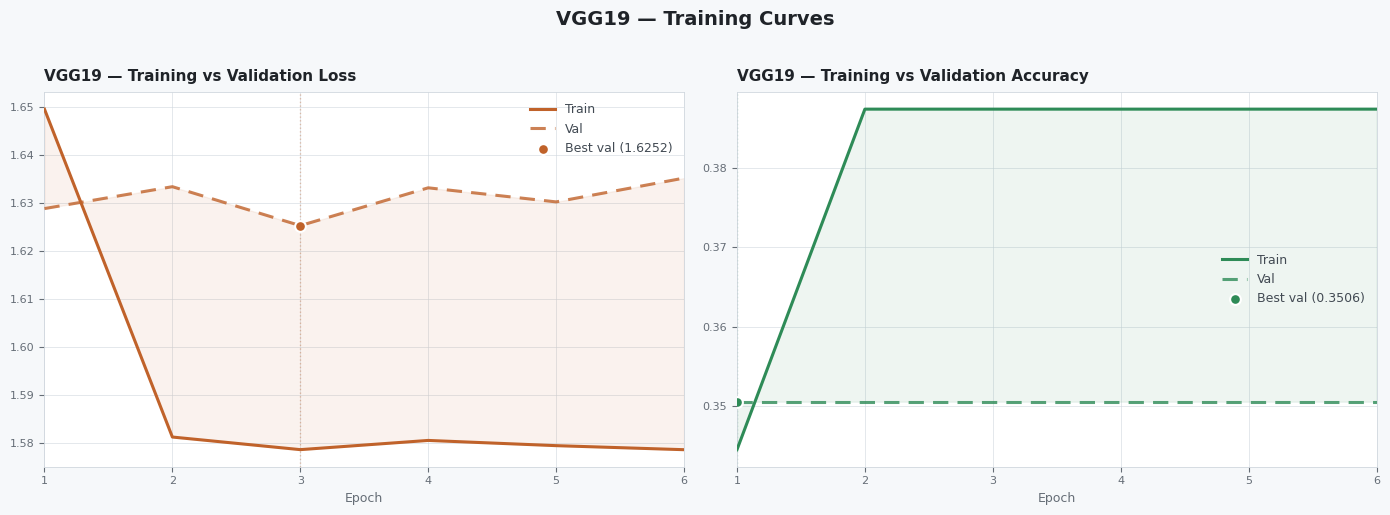

✅  Confusion matrix saved → outputs/vgg19_—_confusion_matrix.png


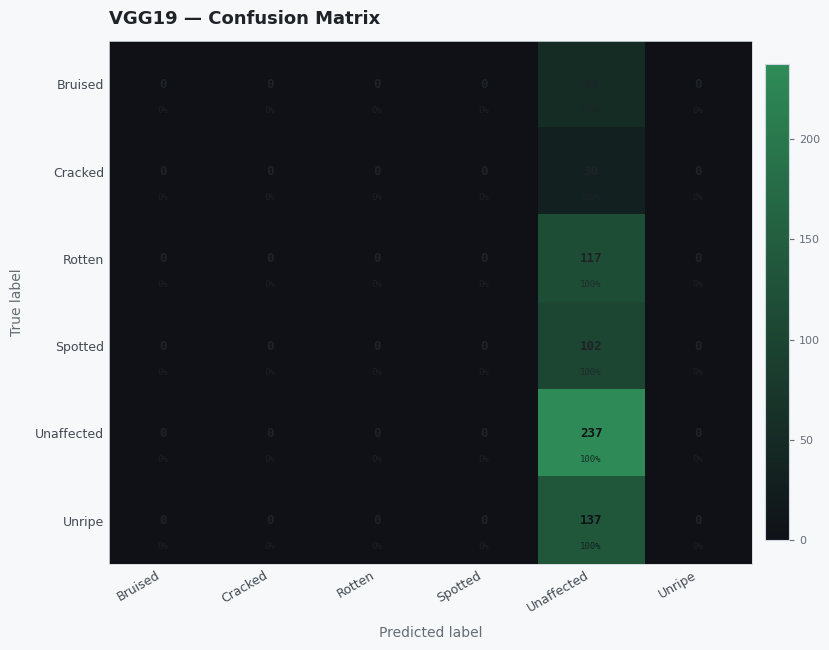

In [15]:
# ============================================================
# VGG19
# ============================================================

from torchvision.models import vgg19
import torch
import torch.nn as nn

model = vgg19(weights=None)
model.classifier[6] = nn.Linear(model.classifier[6].in_features, 6)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

results = train_and_evaluate(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    class_names=AfricanPlumsDataset.CATEGORIES,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=30,
    patience=5,
    save_best=True,
    checkpoint_path="best_vgg19.pth",
    model_name="VGG19",
    save_dir="outputs/",
    dark=False,
)

🖥️   Device : cpu

🚀  Training  ResNet18  for up to 30 epochs …
    Early stopping patience : 5
    Save best checkpoint   : True → best_resnet18.pth

  Epoch [  1/30]  Train Loss: 1.3691  Acc: 0.4986  │  Val Loss: 1.2464  Acc: 0.5414  (211.0s)
    💾  New best val acc 0.5414 — checkpoint saved
  Epoch [  2/30]  Train Loss: 1.2152  Acc: 0.5544  │  Val Loss: 1.2412  Acc: 0.5459  (191.8s)
    💾  New best val acc 0.5459 — checkpoint saved
  Epoch [  3/30]  Train Loss: 1.1603  Acc: 0.5753  │  Val Loss: 1.1418  Acc: 0.5592  (191.8s)
    💾  New best val acc 0.5592 — checkpoint saved
  Epoch [  4/30]  Train Loss: 1.1180  Acc: 0.5912  │  Val Loss: 0.9988  Acc: 0.6746  (191.1s)
    💾  New best val acc 0.6746 — checkpoint saved
  Epoch [  5/30]  Train Loss: 1.0812  Acc: 0.6095  │  Val Loss: 1.0437  Acc: 0.6183  (193.6s)
  Epoch [  6/30]  Train Loss: 1.0410  Acc: 0.6309  │  Val Loss: 0.9508  Acc: 0.6612  (190.6s)
  Epoch [  7/30]  Train Loss: 1.0146  Acc: 0.6207  │  Val Loss: 0.9930  Acc: 0.6376  

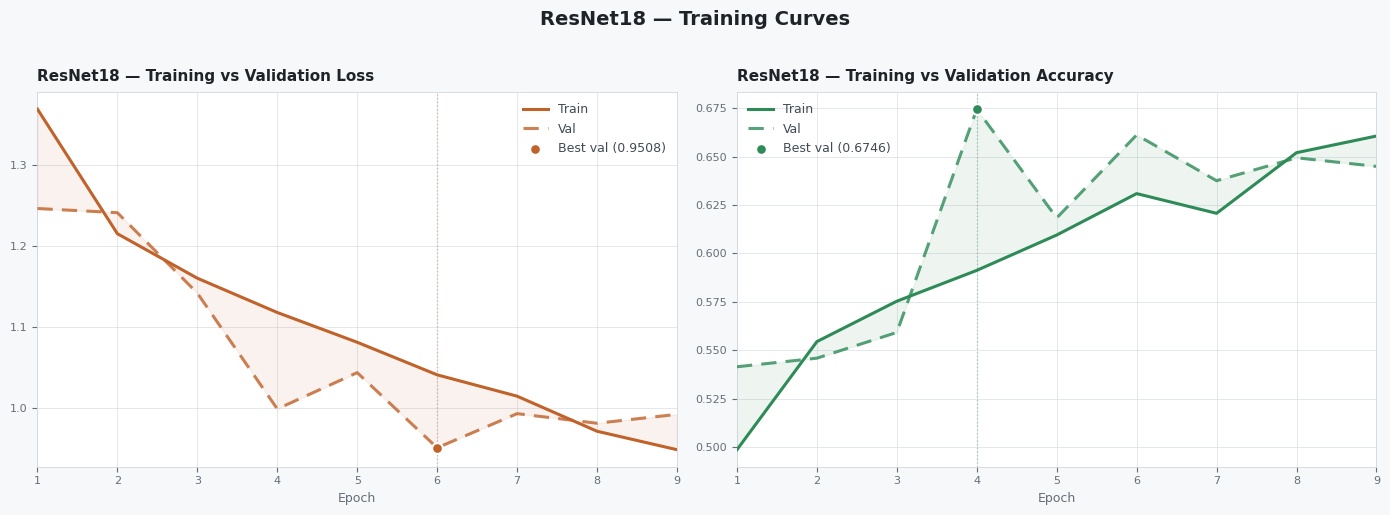

✅  Confusion matrix saved → outputs/resnet18_—_confusion_matrix.png


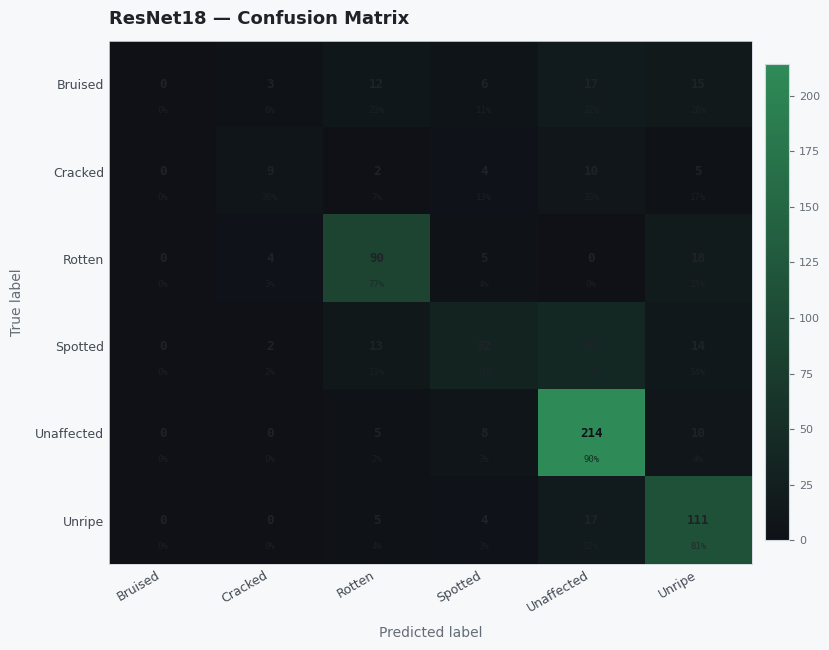

In [19]:
# ============================================================
# ResNet18
# ============================================================

from torchvision.models import resnet18
import torch
import torch.nn as nn

model = resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 6)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

results = train_and_evaluate(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    class_names=AfricanPlumsDataset.CATEGORIES,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=30,
    patience=5,
    save_best=True,
    checkpoint_path="best_resnet18.pth",
    model_name="ResNet18",
    save_dir="outputs/",
    dark=False,
)

🖥️   Device : cpu

🚀  Training  ResNet50  for up to 30 epochs …
    Early stopping patience : 5
    Save best checkpoint   : True → best_resnet50.pth

  Epoch [  1/30]  Train Loss: 1.5258  Acc: 0.4430  │  Val Loss: 1.4251  Acc: 0.4985  (636.7s)
    💾  New best val acc 0.4985 — checkpoint saved
  Epoch [  2/30]  Train Loss: 1.3531  Acc: 0.5228  │  Val Loss: 1.4757  Acc: 0.4837  (623.6s)
  Epoch [  3/30]  Train Loss: 1.3208  Acc: 0.5231  │  Val Loss: 1.2109  Acc: 0.5710  (643.4s)
    💾  New best val acc 0.5710 — checkpoint saved
  Epoch [  4/30]  Train Loss: 1.2351  Acc: 0.5552  │  Val Loss: 1.1796  Acc: 0.6065  (675.0s)
    💾  New best val acc 0.6065 — checkpoint saved
  Epoch [  5/30]  Train Loss: 1.1809  Acc: 0.5777  │  Val Loss: 1.1389  Acc: 0.5754  (5949.9s)
  Epoch [  6/30]  Train Loss: 1.1828  Acc: 0.5839  │  Val Loss: 1.1469  Acc: 0.6080  (746.5s)
    💾  New best val acc 0.6080 — checkpoint saved
  Epoch [  7/30]  Train Loss: 1.1446  Acc: 0.5962  │  Val Loss: 1.0420  Acc: 0.6361 

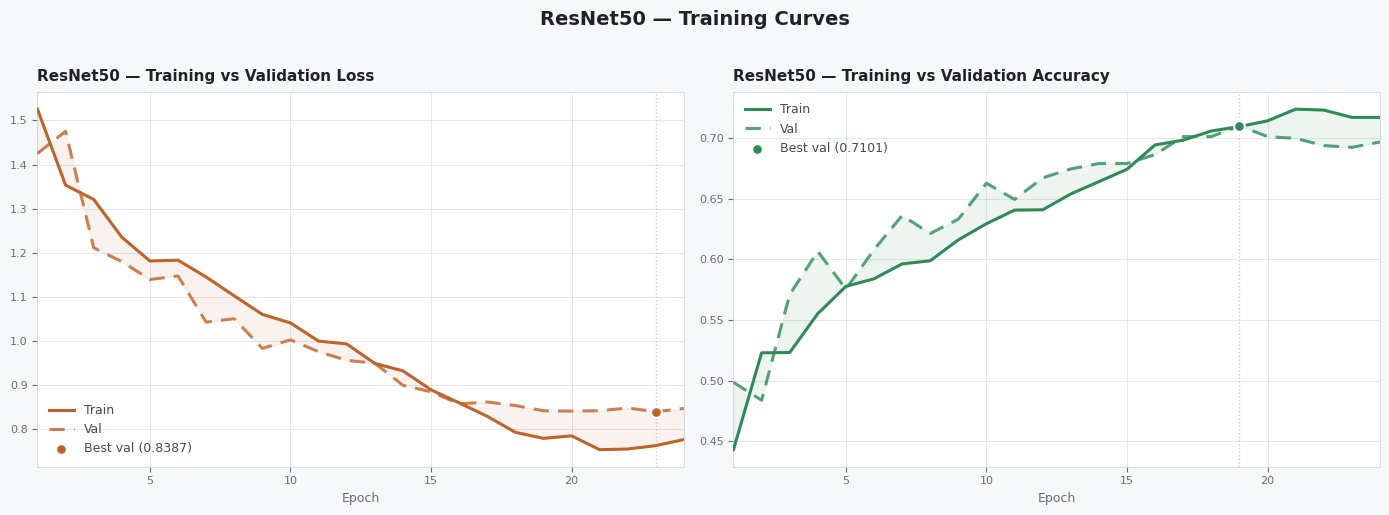

✅  Confusion matrix saved → outputs/resnet50_—_confusion_matrix.png


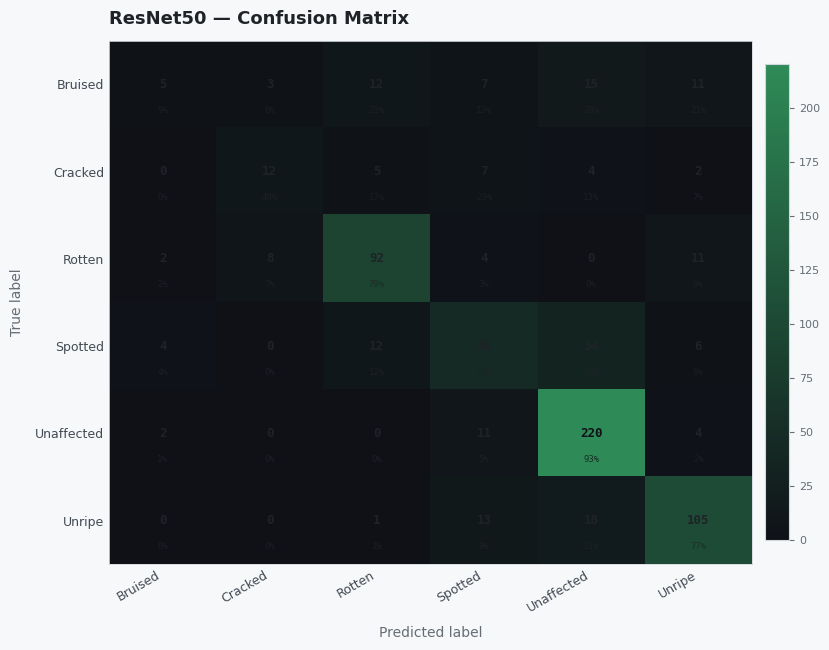

In [18]:
# ============================================================
# ResNet50
# ============================================================

from torchvision.models import resnet50
import torch
import torch.nn as nn

model = resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, 6)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

results = train_and_evaluate(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    class_names=AfricanPlumsDataset.CATEGORIES,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=30,
    patience=5,
    save_best=True,
    checkpoint_path="best_resnet50.pth",
    model_name="ResNet50",
    save_dir="outputs/",
    dark=False,
)

🖥️   Device : cpu

🚀  Training  DenseNet121  for up to 30 epochs …
    Early stopping patience : 5
    Save best checkpoint   : True → best_densenet121.pth

  Epoch [  1/30]  Train Loss: 1.3540  Acc: 0.4991  │  Val Loss: 1.2489  Acc: 0.5355  (802.3s)
    💾  New best val acc 0.5355 — checkpoint saved
  Epoch [  2/30]  Train Loss: 1.2327  Acc: 0.5542  │  Val Loss: 1.1860  Acc: 0.5695  (743.7s)
    💾  New best val acc 0.5695 — checkpoint saved
  Epoch [  3/30]  Train Loss: 1.1973  Acc: 0.5656  │  Val Loss: 1.1607  Acc: 0.5873  (794.4s)
    💾  New best val acc 0.5873 — checkpoint saved
  Epoch [  4/30]  Train Loss: 1.1649  Acc: 0.5790  │  Val Loss: 1.1311  Acc: 0.5902  (784.5s)
    💾  New best val acc 0.5902 — checkpoint saved
  Epoch [  5/30]  Train Loss: 1.1207  Acc: 0.5923  │  Val Loss: 1.1185  Acc: 0.6124  (791.2s)
    💾  New best val acc 0.6124 — checkpoint saved
  Epoch [  6/30]  Train Loss: 1.1039  Acc: 0.5985  │  Val Loss: 1.0562  Acc: 0.6257  (799.8s)
    💾  New best val acc 0.625

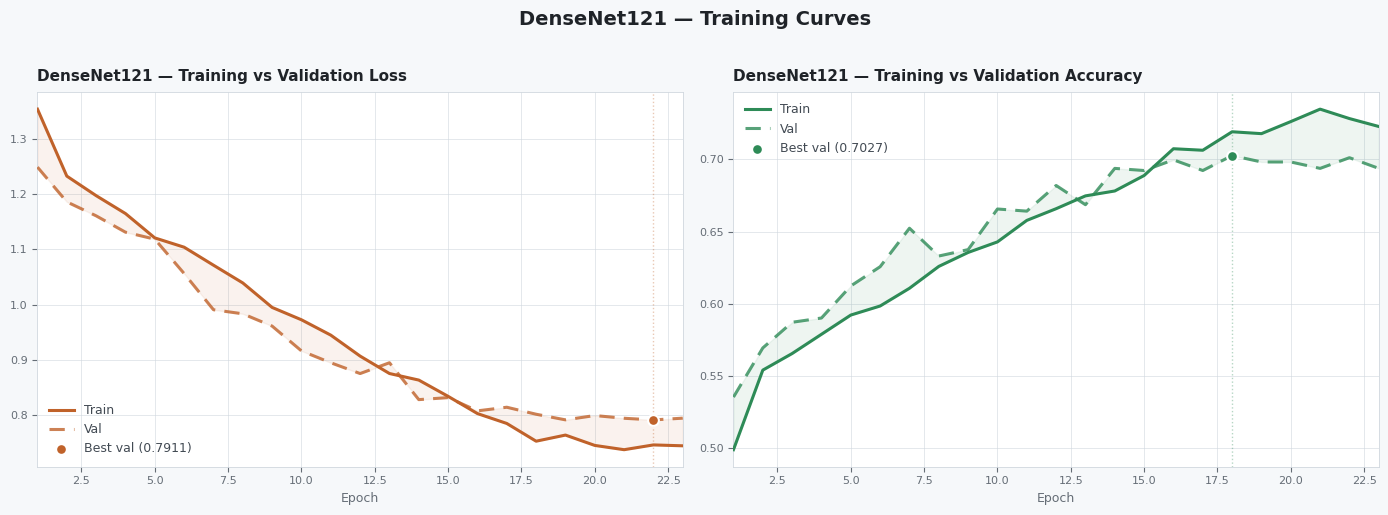

✅  Confusion matrix saved → outputs/densenet121_—_confusion_matrix.png


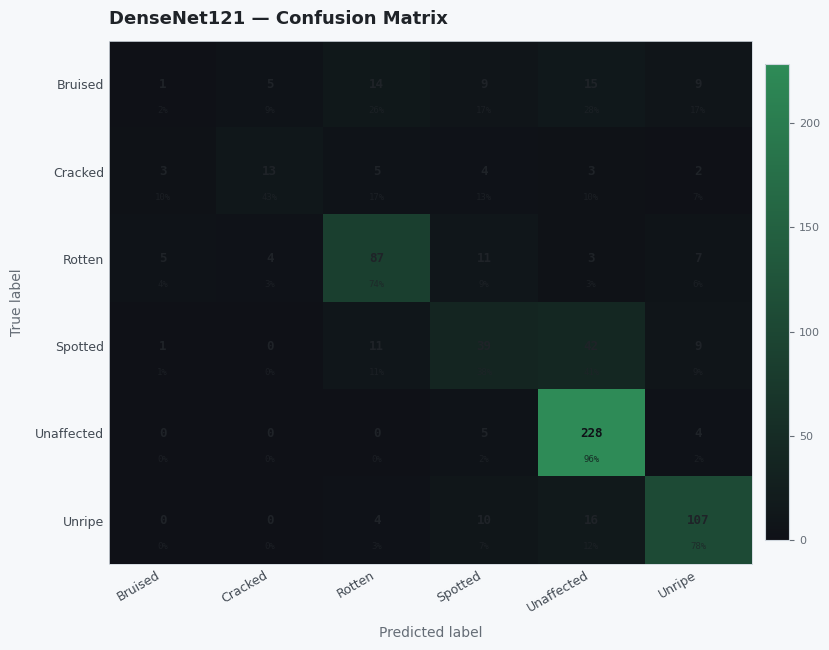

In [17]:
# ============================================================
# DenseNet121
# ============================================================

from torchvision.models import densenet121
import torch
import torch.nn as nn

model = densenet121(weights=None)
model.classifier = nn.Linear(model.classifier.in_features, 6)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

results = train_and_evaluate(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    class_names=AfricanPlumsDataset.CATEGORIES,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=30,
    patience=5,
    save_best=True,
    checkpoint_path="best_densenet121.pth",
    model_name="DenseNet121",
    save_dir="outputs/",
    dark=False,
)

🖥️   Device : cpu

🚀  Training  MobileNetV2  for up to 30 epochs …
    Early stopping patience : 5
    Save best checkpoint   : True → best_mobilenet_v2.pth

  Epoch [  1/30]  Train Loss: 1.4510  Acc: 0.4456  │  Val Loss: 1.3415  Acc: 0.5059  (386.2s)
    💾  New best val acc 0.5059 — checkpoint saved
  Epoch [  2/30]  Train Loss: 1.2967  Acc: 0.5145  │  Val Loss: 1.3347  Acc: 0.5237  (418.0s)
    💾  New best val acc 0.5237 — checkpoint saved
  Epoch [  3/30]  Train Loss: 1.2744  Acc: 0.5210  │  Val Loss: 1.2633  Acc: 0.5577  (349.3s)
    💾  New best val acc 0.5577 — checkpoint saved
  Epoch [  4/30]  Train Loss: 1.2351  Acc: 0.5448  │  Val Loss: 1.2204  Acc: 0.5562  (330.8s)
  Epoch [  5/30]  Train Loss: 1.1831  Acc: 0.5685  │  Val Loss: 1.1400  Acc: 0.5784  (328.0s)
    💾  New best val acc 0.5784 — checkpoint saved
  Epoch [  6/30]  Train Loss: 1.1703  Acc: 0.5743  │  Val Loss: 1.1275  Acc: 0.5814  (325.7s)
    💾  New best val acc 0.5814 — checkpoint saved
  Epoch [  7/30]  Train Loss

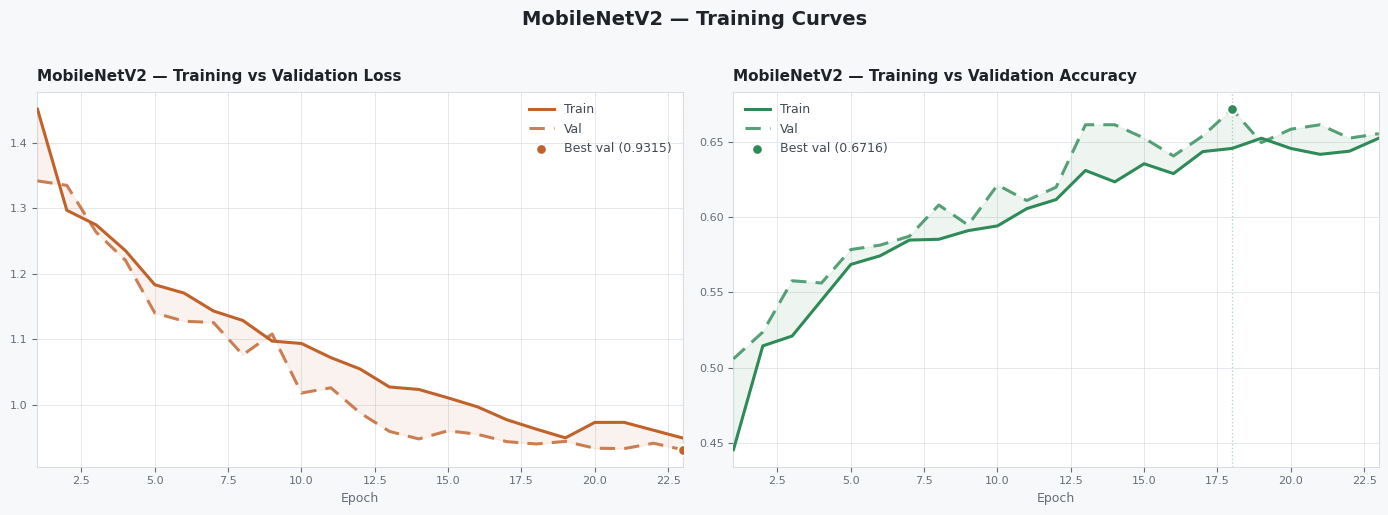

✅  Confusion matrix saved → outputs/mobilenetv2_—_confusion_matrix.png


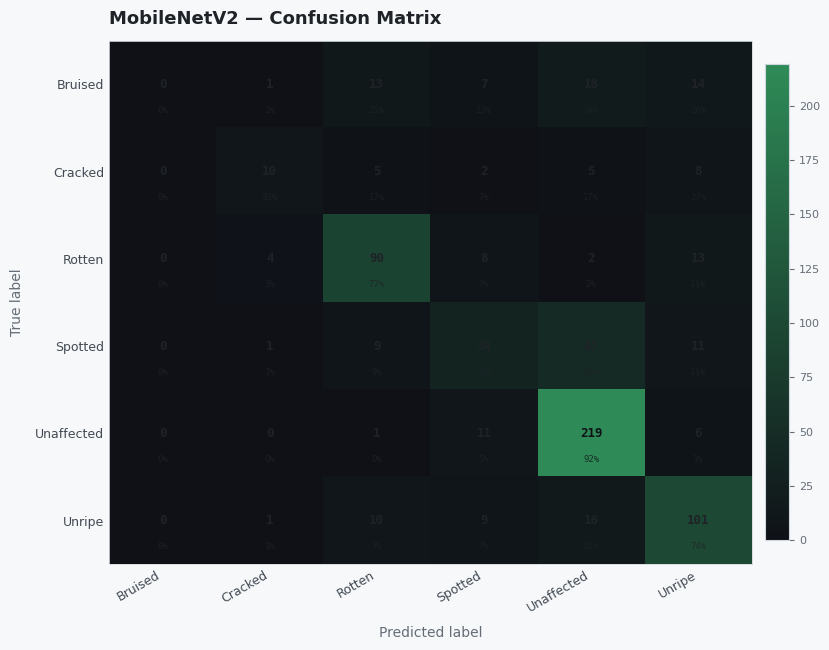

In [16]:
# ============================================================
# MobileNetV2
# ============================================================

from torchvision.models import mobilenet_v2
import torch
import torch.nn as nn

model = mobilenet_v2(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 6)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

results = train_and_evaluate(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    class_names=AfricanPlumsDataset.CATEGORIES,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=30,
    patience=5,
    save_best=True,
    checkpoint_path="best_mobilenet_v2.pth",
    model_name="MobileNetV2",
    save_dir="outputs/",
    dark=False,
)

🖥️   Device : cpu

🚀  Training  MobileNetV3Large  for up to 30 epochs …
    Early stopping patience : 5
    Save best checkpoint   : True → best_mobilenet_v3_large.pth

  Epoch [  1/30]  Train Loss: 1.4525  Acc: 0.4484  │  Val Loss: 1.6834  Acc: 0.3506  (221.5s)
    💾  New best val acc 0.3506 — checkpoint saved
  Epoch [  2/30]  Train Loss: 1.3132  Acc: 0.5077  │  Val Loss: 1.6785  Acc: 0.3506  (229.7s)
  Epoch [  3/30]  Train Loss: 1.2454  Acc: 0.5440  │  Val Loss: 1.7039  Acc: 0.3506  (199.4s)
  Epoch [  4/30]  Train Loss: 1.1817  Acc: 0.5662  │  Val Loss: 1.7954  Acc: 0.3506  (196.8s)
  Epoch [  5/30]  Train Loss: 1.1445  Acc: 0.5889  │  Val Loss: 1.8515  Acc: 0.3595  (196.0s)
    💾  New best val acc 0.3595 — checkpoint saved
  Epoch [  6/30]  Train Loss: 1.1087  Acc: 0.5972  │  Val Loss: 1.3114  Acc: 0.5325  (199.8s)
    💾  New best val acc 0.5325 — checkpoint saved
  Epoch [  7/30]  Train Loss: 1.0688  Acc: 0.6111  │  Val Loss: 1.0271  Acc: 0.6331  (197.0s)
    💾  New best val acc

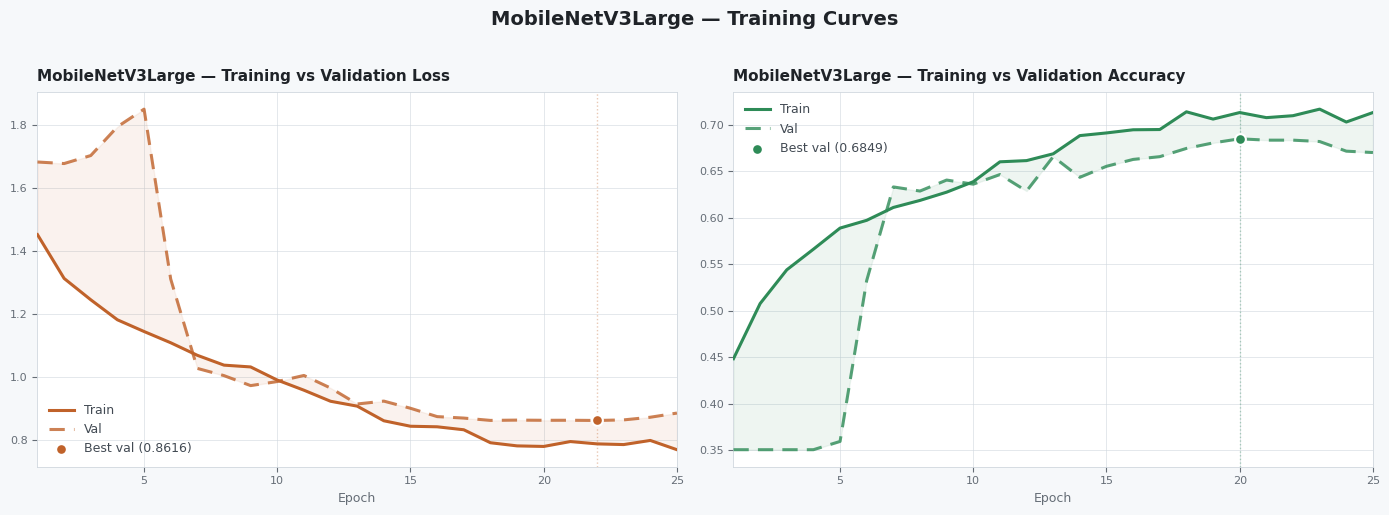

✅  Confusion matrix saved → outputs/mobilenetv3large_—_confusion_matrix.png


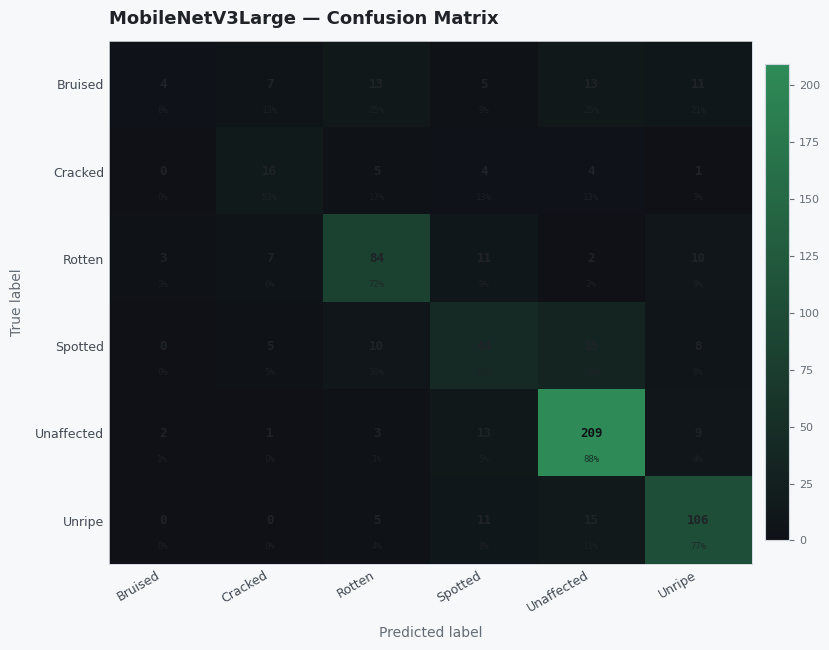

In [19]:
# ============================================================
# MobileNetV3 Large
# ============================================================

from torchvision.models import mobilenet_v3_large
import torch
import torch.nn as nn

model = mobilenet_v3_large(weights=None)
model.classifier[3] = nn.Linear(model.classifier[3].in_features, 6)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

results = train_and_evaluate(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    class_names=AfricanPlumsDataset.CATEGORIES,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=30,
    patience=5,
    save_best=True,
    checkpoint_path="best_mobilenet_v3_large.pth",
    model_name="MobileNetV3Large",
    save_dir="outputs/",
    dark=False,
)

🖥️   Device : cpu

🚀  Training  ShuffleNetV2  for up to 30 epochs …
    Early stopping patience : 5
    Save best checkpoint   : True → best_shufflenetv2.pth

  Epoch [  1/30]  Train Loss: 1.4529  Acc: 0.4396  │  Val Loss: 1.2863  Acc: 0.5266  (130.4s)
    💾  New best val acc 0.5266 — checkpoint saved
  Epoch [  2/30]  Train Loss: 1.2772  Acc: 0.5249  │  Val Loss: 1.3800  Acc: 0.4970  (131.1s)
  Epoch [  3/30]  Train Loss: 1.2388  Acc: 0.5440  │  Val Loss: 1.2102  Acc: 0.5636  (128.4s)
    💾  New best val acc 0.5636 — checkpoint saved
  Epoch [  4/30]  Train Loss: 1.2239  Acc: 0.5445  │  Val Loss: 1.1779  Acc: 0.5592  (110.5s)
  Epoch [  5/30]  Train Loss: 1.1859  Acc: 0.5722  │  Val Loss: 1.1290  Acc: 0.5814  (96.6s)
    💾  New best val acc 0.5814 — checkpoint saved
  Epoch [  6/30]  Train Loss: 1.1734  Acc: 0.5709  │  Val Loss: 1.1347  Acc: 0.5784  (94.6s)
  Epoch [  7/30]  Train Loss: 1.1392  Acc: 0.5860  │  Val Loss: 1.1151  Acc: 0.5932  (93.6s)
    💾  New best val acc 0.5932 — che

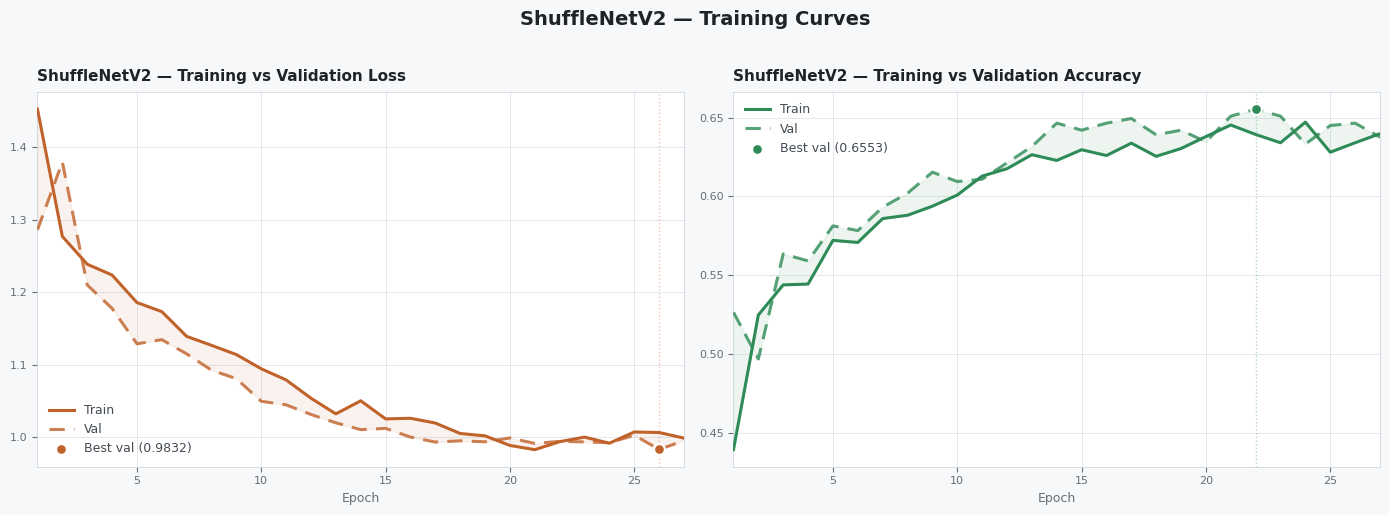

✅  Confusion matrix saved → outputs/shufflenetv2_—_confusion_matrix.png


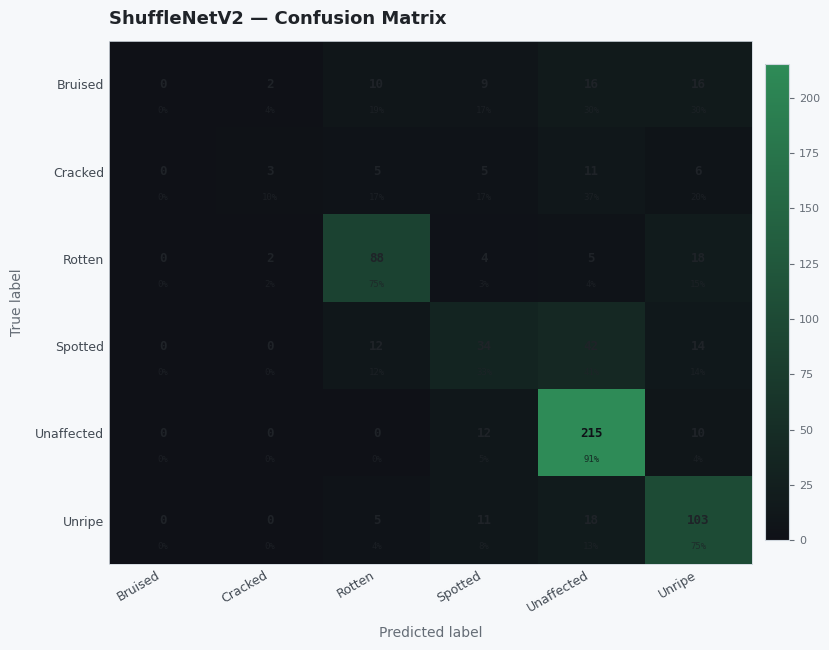

In [18]:
# ============================================================
# ShuffleNetV2
# ============================================================

from torchvision.models import shufflenet_v2_x1_0
import torch
import torch.nn as nn

model = shufflenet_v2_x1_0(weights=None)
model.fc = nn.Linear(model.fc.in_features, 6)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

results = train_and_evaluate(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    class_names=AfricanPlumsDataset.CATEGORIES,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=30,
    patience=5,
    save_best=True,
    checkpoint_path="best_shufflenetv2.pth",
    model_name="ShuffleNetV2",
    save_dir="outputs/",
    dark=False,
)

🖥️   Device : cpu

🚀  Training  SqueezeNet1_1  for up to 30 epochs …
    Early stopping patience : 5
    Save best checkpoint   : True → best_squeezenet.pth

  Epoch [  1/30]  Train Loss: 1.5049  Acc: 0.4297  │  Val Loss: 1.4335  Acc: 0.4379  (110.3s)
    💾  New best val acc 0.4379 — checkpoint saved
  Epoch [  2/30]  Train Loss: 1.3972  Acc: 0.4641  │  Val Loss: 1.4726  Acc: 0.4231  (108.0s)
  Epoch [  3/30]  Train Loss: 1.3540  Acc: 0.5127  │  Val Loss: 1.3276  Acc: 0.5222  (102.5s)
    💾  New best val acc 0.5222 — checkpoint saved
  Epoch [  4/30]  Train Loss: 1.3062  Acc: 0.5202  │  Val Loss: 1.2554  Acc: 0.5370  (102.7s)
    💾  New best val acc 0.5370 — checkpoint saved
  Epoch [  5/30]  Train Loss: 1.2813  Acc: 0.5325  │  Val Loss: 1.2550  Acc: 0.5325  (102.3s)
  Epoch [  6/30]  Train Loss: 1.2348  Acc: 0.5531  │  Val Loss: 1.1933  Acc: 0.5695  (101.1s)
    💾  New best val acc 0.5695 — checkpoint saved
  Epoch [  7/30]  Train Loss: 1.2171  Acc: 0.5568  │  Val Loss: 1.2463  Acc: 0

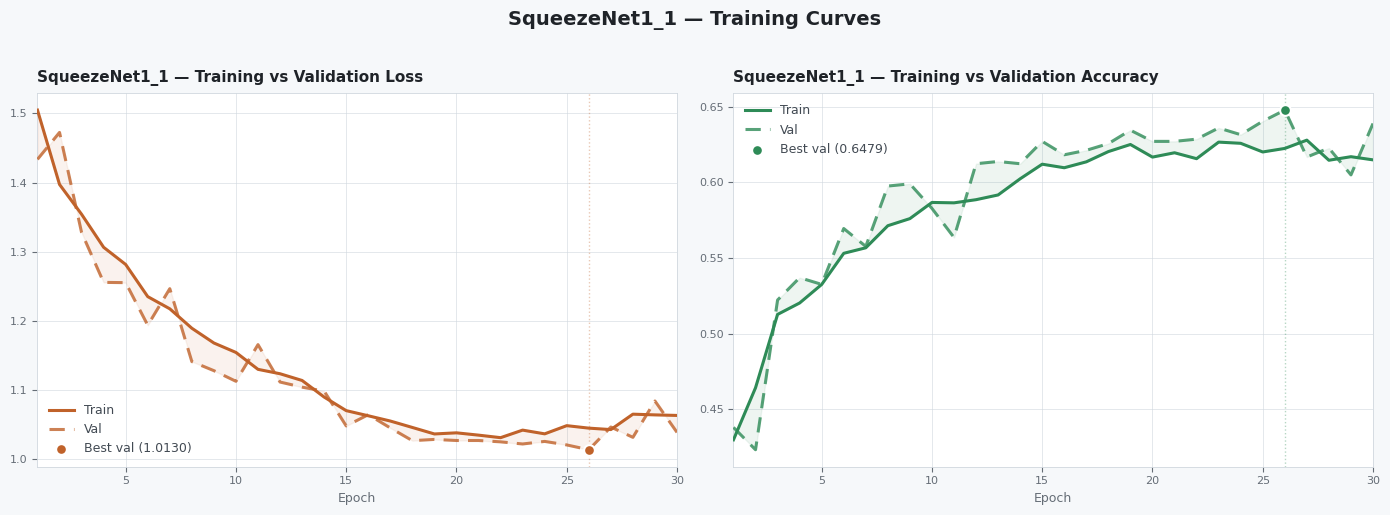

✅  Confusion matrix saved → outputs/squeezenet1_1_—_confusion_matrix.png


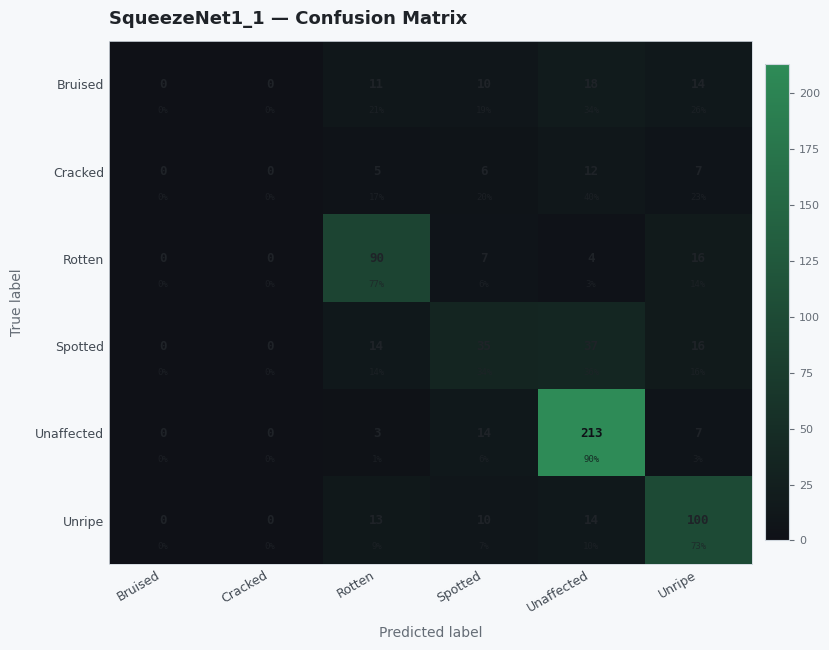

In [17]:
# ============================================================
# SqueezeNet1_1
# ============================================================

from torchvision.models import squeezenet1_1
import torch
import torch.nn as nn

model = squeezenet1_1(weights=None)

model.classifier[1] = nn.Conv2d(
    512,
    6,
    kernel_size=(1, 1)
)

model.num_classes = 6

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

results = train_and_evaluate(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    class_names=AfricanPlumsDataset.CATEGORIES,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=30,
    patience=5,
    save_best=True,
    checkpoint_path="best_squeezenet.pth",
    model_name="SqueezeNet1_1",
    save_dir="outputs/",
    dark=False,
)

🖥️   Device : cpu

🚀  Training  ConvNeXtTiny  for up to 30 epochs …
    Early stopping patience : 5
    Save best checkpoint   : True → best_convnext_tiny.pth

  Epoch [  1/30]  Train Loss: 1.6211  Acc: 0.3965  │  Val Loss: 1.4100  Acc: 0.4896  (593.6s)
    💾  New best val acc 0.4896 — checkpoint saved
  Epoch [  2/30]  Train Loss: 1.3591  Acc: 0.4960  │  Val Loss: 1.3549  Acc: 0.5163  (648.1s)
    💾  New best val acc 0.5163 — checkpoint saved
  Epoch [  3/30]  Train Loss: 1.3122  Acc: 0.5270  │  Val Loss: 1.2589  Acc: 0.5340  (514.8s)
    💾  New best val acc 0.5340 — checkpoint saved
  Epoch [  4/30]  Train Loss: 1.2847  Acc: 0.5364  │  Val Loss: 1.2333  Acc: 0.5636  (484.3s)
    💾  New best val acc 0.5636 — checkpoint saved
  Epoch [  5/30]  Train Loss: 1.2487  Acc: 0.5497  │  Val Loss: 1.2418  Acc: 0.5621  (487.4s)
  Epoch [  6/30]  Train Loss: 1.2365  Acc: 0.5518  │  Val Loss: 1.2141  Acc: 0.5562  (9993.9s)
  Epoch [  7/30]  Train Loss: 1.2212  Acc: 0.5516  │  Val Loss: 1.1926  Acc

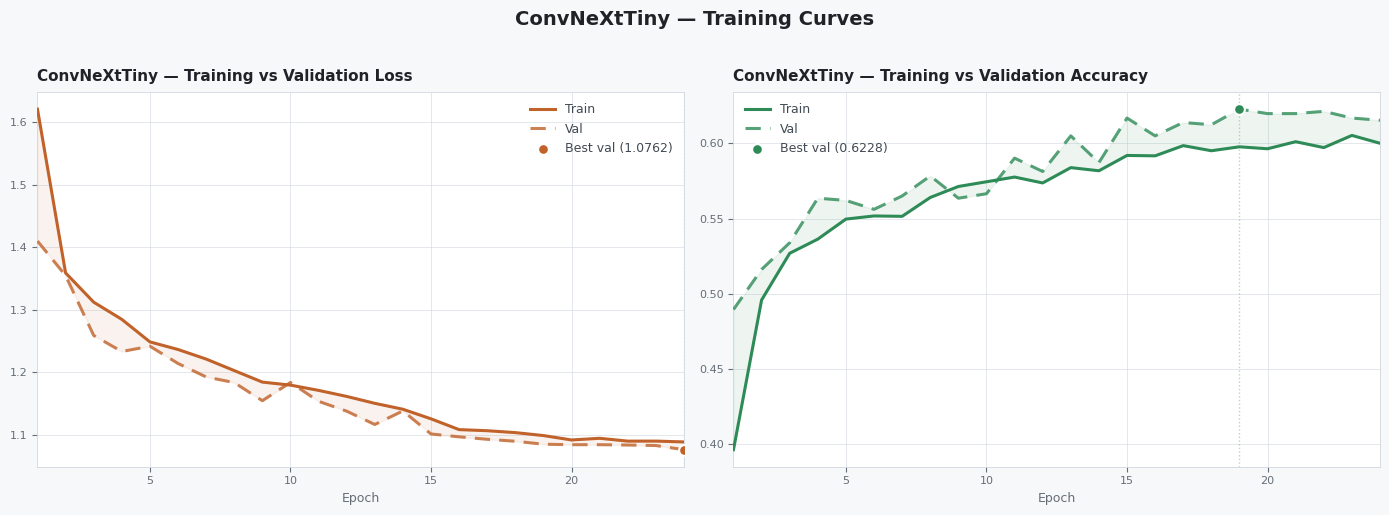

✅  Confusion matrix saved → outputs/convnexttiny_—_confusion_matrix.png


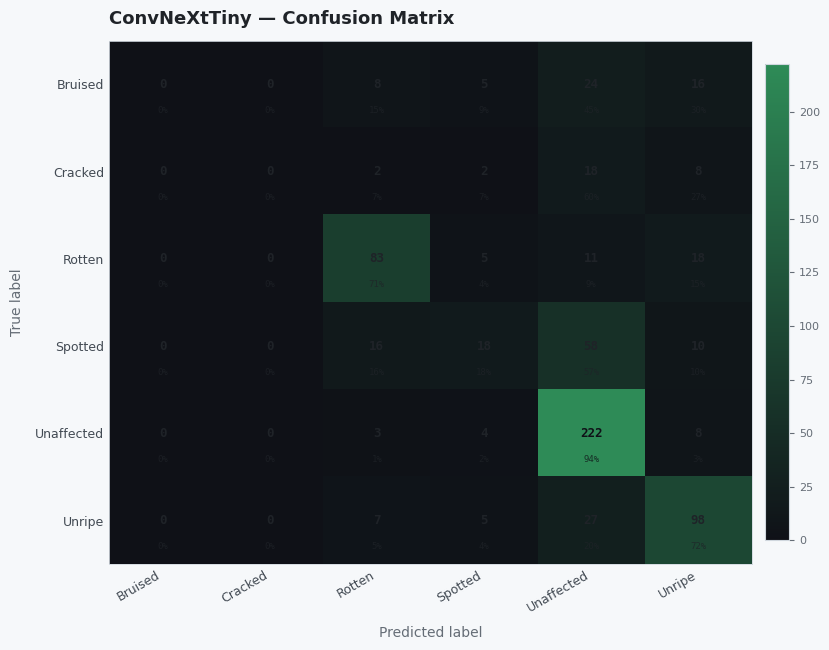

In [16]:
# ============================================================
# ConvNeXt Tiny
# ============================================================

from torchvision.models import convnext_tiny
import torch
import torch.nn as nn

model = convnext_tiny(weights=None)
model.classifier[2] = nn.Linear(model.classifier[2].in_features, 6)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

results = train_and_evaluate(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    class_names=AfricanPlumsDataset.CATEGORIES,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=30,
    patience=5,
    save_best=True,
    checkpoint_path="best_convnext_tiny.pth",
    model_name="ConvNeXtTiny",
    save_dir="outputs/",
    dark=False,
)

🖥️   Device : cpu

🚀  Training  ViT_B_16  for up to 30 epochs …
    Early stopping patience : 5
    Save best checkpoint   : True → best_vit_b16.pth

  Epoch [  1/30]  Train Loss: 1.6859  Acc: 0.4364  │  Val Loss: 1.4629  Acc: 0.4852  (4431.7s)
    💾  New best val acc 0.4852 — checkpoint saved
  Epoch [  2/30]  Train Loss: 1.4083  Acc: 0.4790  │  Val Loss: 1.5251  Acc: 0.4364  (1291.0s)
  Epoch [  3/30]  Train Loss: 1.3766  Acc: 0.4894  │  Val Loss: 1.3559  Acc: 0.5163  (2084.4s)
    💾  New best val acc 0.5163 — checkpoint saved
  Epoch [  4/30]  Train Loss: 1.3561  Acc: 0.5040  │  Val Loss: 1.3301  Acc: 0.5178  (1415.4s)
    💾  New best val acc 0.5178 — checkpoint saved
  Epoch [  5/30]  Train Loss: 1.3233  Acc: 0.5108  │  Val Loss: 1.3440  Acc: 0.5030  (1927.2s)
  Epoch [  6/30]  Train Loss: 1.2800  Acc: 0.5273  │  Val Loss: 1.3488  Acc: 0.4970  (1506.1s)
  Epoch [  7/30]  Train Loss: 1.3035  Acc: 0.5202  │  Val Loss: 1.3298  Acc: 0.5192  (1586.7s)
    💾  New best val acc 0.5192 — ch

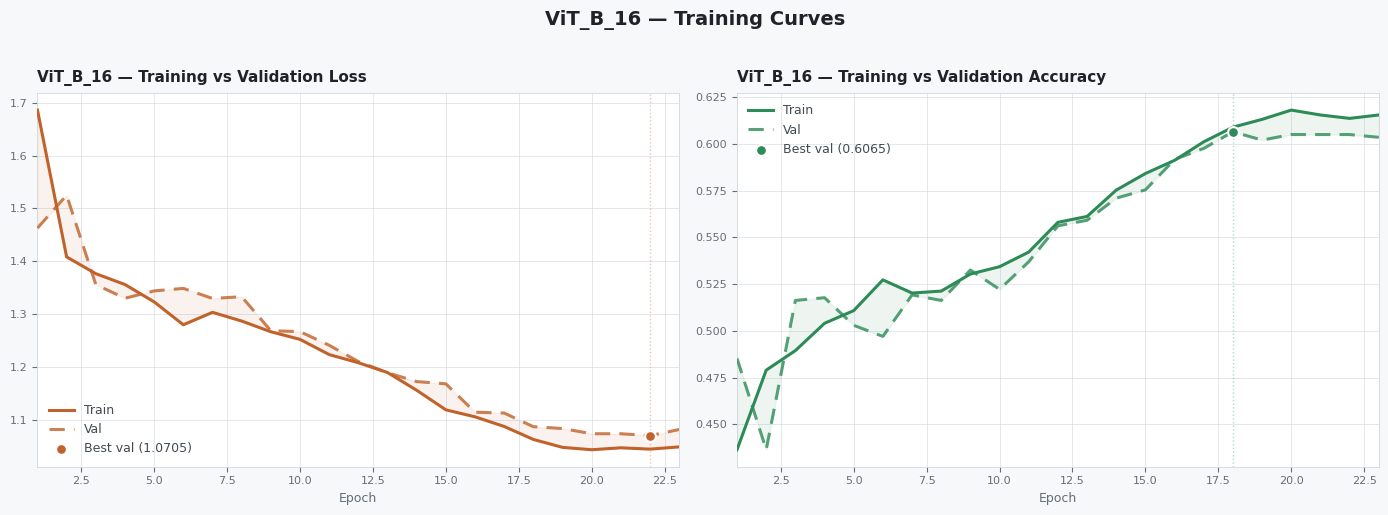

✅  Confusion matrix saved → outputs/vit_b_16_—_confusion_matrix.png


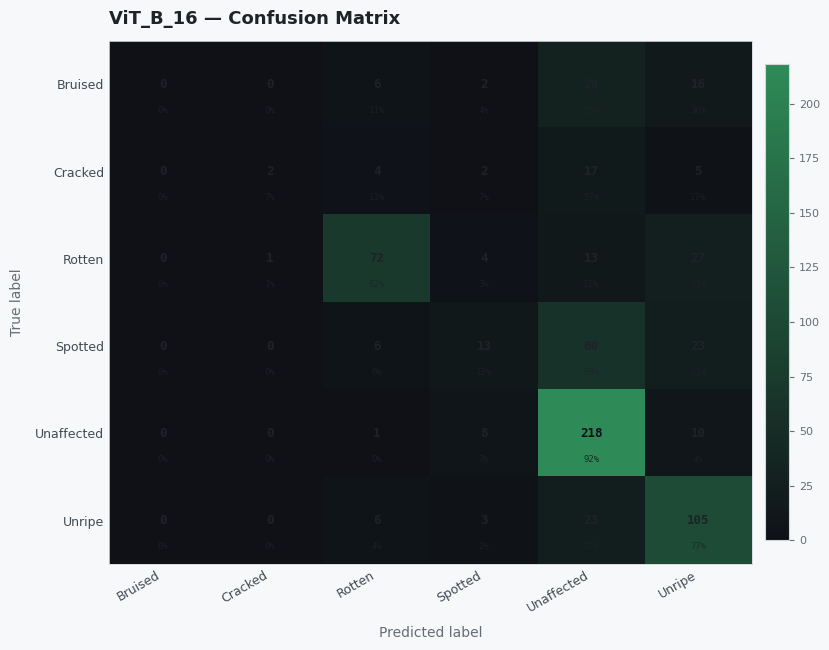

In [15]:
# ============================================================
# Vision Transformer (ViT-B-16)
# ============================================================

from torchvision.models import vit_b_16
import torch
import torch.nn as nn

model = vit_b_16(weights=None)
model.heads.head = nn.Linear(model.heads.head.in_features, 6)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

results = train_and_evaluate(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    class_names=AfricanPlumsDataset.CATEGORIES,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=30,
    patience=5,
    save_best=True,
    checkpoint_path="best_vit_b16.pth",
    model_name="ViT_B_16",
    save_dir="outputs/",
    dark=False,
)